<a href="https://colab.research.google.com/github/mugalan/introduction-to-statistical-learning/blob/main/review_of_probability_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Foundations of Probability Spaces

The notion of **probability** quantifies the **likelihood** of an **event occurring**, interpreted either as a long-run frequency or as a degree of belief based on available information.

In measure theory, we treat the sample space $\Omega$ as the "universal set" where every underlying outcome is a point $\omega \in \Omega$. In practice, these individual outcomes are often not directly observable. Instead, what we observe are coarser collections of outcomes, which we formalize as events in a $\sigma$-algebra $\mathscr{F}$. For example, in a balloon filled with an ideal gas, the sample space $\Omega$ consists of all possible microstates (the exact positions and velocities of every molecule, totaling on the order of $10^{23}$ particles). However, we can only observe macroscopic properties—like temperature or pressure. A single observable macrostate corresponds to a massive collection of microstates, forming a measurable event $A \in \mathscr{F}$.

> **An Event is a Subset.**
> If $\Omega$ is the universe of "what could happen," then an **event $A$** is simply a collection of specific outcomes, making $A$ a **subset** of $\Omega$ ($A \subseteq \Omega$). It can be viewed as a yes-or-no question about the experiment: "Did the outcome lie in $A$?".

 Consequently, logical operations on events translate directly into set operations on subsets: the occurrence of **"A or B"** is the **union** ($A \cup B$), **"A and B"** is the **intersection** ($A \cap B$), and **"not A"** is the **complement** ($A^c$). Under this mapping, the probability $P(A)$ is simply the "size" or **measure** of the subset $A$ relative to the total measure of the universe $\Omega$.

When the sample space $\Omega$ is countable (either finite or countably infinite), we call it a **discrete sample space**. On the otherhand, when the sample space $\Omega$ is uncountable (such as an interval in $\mathbb{R}$ or a region in $\mathbb{R}^n$), we call it a **continuous sample space**.

In the following we formalize these notions in a concrete way.

## 1.1 $\sigma$-algebras

### 1.1.1 The Need for $\sigma$-algebras

In elementary probability (like coin flips or dice rolls), $\Omega$ is finite. In these cases, our intuition tells us that every imaginable collection of outcomes (an event) should have a probability. However this is not true of infinite sample spaces. For example there is no way to assign a probability to all subsets of
$\mathbb{R}$ while preserving countable additivity. To resolve this, we restrict our attention to a collection of "well-behaved" subsets called a **$\sigma$-algebra**. More conceptually, a sigma-algebra is a collection of events (each event capturing yes/no questions) that are regarded as meaningful or observable.


In essence, a $\sigma$-algebra represents "**available information**" because its granularity determines which events we can actually distinguish.

If a specific subset is not in our $\sigma$-algebra, our "information set" is too coarse to determine whether that event occurred, effectively treating its internal details as unobservable noise.

>A smaller $\sigma$-algebra means you have less "resolution" or "granularity" or "information" regarding the outcome.

### 1.1.2 Definition: $\sigma$-algebra



Let $\Omega$ be a non-empty set (the sample space). A collection $\mathfrak{F}$ of subsets of $\Omega$ is called a **$\sigma$-algebra** if it satisfies the following three axioms:

1. **Contains the empty set:**

$$\emptyset \in \mathfrak{F}$$


2. **Closed under complementation:**
If $A \in \mathfrak{F}$, then $A^c \in \mathfrak{F}$
*(If we can measure the probability of an event happening, we must be able to measure the probability of it not happening.)*
3. **Closed under countable unions:**
If $A_1, A_2, A_3, \dots \in \mathfrak{F}$, then $\bigcup_{n=1}^{\infty} A_n \in \mathfrak{F}$
*(This is the critical "measure-theoretic" leap from finite to infinite processes, allowing us to handle limits.)*



#### Key Consequences

From these axioms, it follows that a $\sigma$-algebra is also closed under **countable intersections**:


$$\bigcap_{n=1}^{\infty} A_n = \left( \bigcup_{n=1}^{\infty} A_n^c \right)^c \in \mathfrak{F}$$



#### Numerical Intuition: Simulating the Breakdown

While we cannot "code" an infinite $\sigma$-algebra, we can demonstrate the property of **stability under operations**.


In [ ]:
# Example: Checking if a collection of sets is closed under union (Finite case)
sample_space = {1, 2, 3, 4}
sigma_algebra = [set(), {1, 2}, {3, 4}, {1, 2, 3, 4}]

def is_closed_under_union(collection):
    for a in collection:
        for b in collection:
            if a.union(b) not in collection:
                return False
    return True

print(f"Is the collection closed under union? {is_closed_under_union(sigma_algebra)}")

#### Example #1: The Borel $\sigma$-algebra $\mathfrak{B}(\mathbb{R})$

We often work with $\Omega = \mathbb{R}$. The most important $\sigma$-algebra for the real line is the **Borel $\sigma$-algebra**, denoted $\mathfrak{B}(\mathbb{R})$. It is defined as the smallest $\sigma$-algebra containing all open intervals $(a, b)$.

Most standard sets encountered in analysis — intervals, open/closed sets, countable unions/intersections of these — are Borel.



#### Example #2: The Trivial $\sigma$-algebra

The smallest possible $\sigma$-algebra for any $\Omega$ is the **Trivial $\sigma$-algebra**:


$$\mathfrak{F}_{trivial} = \{ \emptyset, \Omega \}$$


In this case, you can only measure the probability of "nothing happening" ($\emptyset$) or "something happening" ($\Omega$).

#### Example #3: The Power Set

The **Power Set** of a set $\Omega$ is the collection of all possible subsets of $\Omega$, including the empty set and $\Omega$ itself.


Let $\Omega$ be any set. The power set, denoted by $\mathfrak{P}(\Omega)$ or $2^\Omega$, is defined as:


$$\mathfrak{P}(\Omega) = \{ A : A \subseteq \Omega \}$$

---

**Key Properties**

1. **Cardinality:** If a finite set $\Omega$ has $n$ elements, the power set $\mathfrak{P}(\Omega)$ has $2^n$ elements.
* *This is why the notation $2^\Omega$ is often used.*


2. **The "Largest" $\sigma$-algebra:** For any sample space $\Omega$, the power set is the most granular $\sigma$-algebra possible. It allows us to assign a probability to every single individual outcome and every combination of outcomes.

---

**Why is it important in Statistical Learning?**

In many machine learning applications involving discrete features (like "Heads/Tails," "Spam/Not Spam," or "Class A/B/C"), we assume the $\sigma$-algebra is the **power set**. This is because we have no mathematical restriction preventing us from measuring the probability of any specific subset of these discrete outcomes.

---

**Important Note**

While the Power Set works perfectly for finite sets, we **cannot** use the Power Set of the Real Numbers ($\mathbb{R}$) as our $\sigma$-algebra for continuous probability. The Power Set of $\mathbb{R}$ is "too big" and contains sets that are impossible to measure (Non-measurable sets). A standard choice, that avoids this problem, is the Borel $\sigma$-algebra.

#### Example #4: Multiple $\sigma$-algebras on the Same Space

Consider the sample space of a fair die roll:


$$\Omega = \{1, 2, 3, 4, 5, 6\}$$

We can define two different "observers" who have access to different levels of information about the result.

**Observer A:** "The Odd/Even Observer"

This observer only cares (or is only told) if the result was even or odd. They cannot distinguish between a $2$ and a $4$, but they can distinguish between a $2$ and a $3$.

Their $\sigma$-algebra, $\mathfrak{F}_{A}$, is:


$$\mathfrak{F}_{A} = \bigl\{ \emptyset, \{1, 3, 5\}, \{2, 4, 6\}, \Omega \bigr\}$$

* **$\{1, 3, 5\}$** represents the event "The result is Odd."
* **$\{2, 4, 6\}$** represents the event "The result is Even."

**Observer B:** "The High/Low Observer"

This observer only cares if the result was "High" ($>3$) or "Low" ($\leq 3$).

Their $\sigma$-algebra, $\mathfrak{F}_{B}$, is:


$$\mathfrak{F}_{B} = \bigl\{ \emptyset, \{1, 2, 3\}, \{4, 5, 6\}, \Omega \bigr\}$$

* **$\{1, 2, 3\}$** represents the event "The result is Low."
* **$\{4, 5, 6\}$** represents the event "The result is High."

---

**Comparison and Discussion**

* **Both are valid $\sigma$-algebras** on the same $\Omega$. They both contain $\emptyset$ and $\Omega$, and they are closed under complement and union.
* **They are distinct:** The event $\{1, 3, 5\}$ is "measurable" to Observer A, but **not** to Observer B. If the result is High/Low, Observer B literally does not have the "information" to determine if the number was odd or even.
* **Non-Trivial:** Both contain more than just the empty set and the sample space.

---



***Why this matters:**

In **Bayesian Inference**, when we receive a new "observation," we are essentially moving from a smaller $\sigma$-algebra (less information) to a larger one (more information).
This motivates filtrations, which model increasing information over time.

In [ ]:
# Define the sample space
Omega = {1, 2, 3, 4, 5, 6}

# Define the two sigma-algebras
F_A = [set(), {1, 3, 5}, {2, 4, 6}, {1, 2, 3, 4, 5, 6}] # Odd/Even
F_B = [set(), {1, 2, 3}, {4, 5, 6}, {1, 2, 3, 4, 5, 6}] # Low/High

def is_event_measurable(event, sigma_algebra):
    return set(event) in sigma_algebra

# Test an event: "The result was a 1 or 3"
event_to_check = {1, 3}

print(f"Is {{1, 3}} measurable by Observer A? {is_event_measurable(event_to_check, F_A)}")
print(f"Is {{1, 3}} measurable by Observer B? {is_event_measurable(event_to_check, F_B)}")

# Neither can measure {1, 3} because they lack the 'granularity'
# to separate 1 and 3 from 5 (for A) or 1 and 3 from 2 (for B).

#### Example #5 - Two $\sigma$-algebras of the unit disk

Let our sample space be the unit disk:
$$\Omega = \left\{ (x, y) \in \mathbb{R}^2 : x^2 + y^2 \le 1 \right\}$$

1. Vertical Split Partition ($\mathscr{P}_{\text{vertical}}$)
We partition the disk along the y-axis ($x = 0$) into the left and right halves:
$$\textrm{(Right Half)} \quad A_1 = \{ (x, y) \in \Omega : x \ge 0 \}$$
$$\textrm{(Left Half)} A_2 = \{ (x, y) \in \Omega : x < 0 \}$$
The $\sigma$-algebra $\sigma(\mathscr{P}_{\text{vertical}})$ contains exactly $2^2 = 4$ events:$$\sigma(\mathscr{P}_{\text{vertical}}) = \{\emptyset, A_1, A_2, \Omega\}$$

2. Horizontal Split Partition ($\mathscr{P}_{\text{horizontal}}$)We partition the disk along the x-axis ($y = 0$) into the top and bottom halves:
$$\textrm{(Top Half)} \quad B_1 = \{ (x, y) \in \Omega : y \ge 0 \}$$
$$\textrm{(Bottom Half)} \quad B_2 = \{ (x, y) \in \Omega : y < 0 \}$$
(Bottom Half)The $\sigma$-algebra $\sigma(\mathscr{P}_{\text{horizontal}})$ similarly contains exactly $2^2 = 4$ events:$$\sigma(\mathscr{P}_{\text{horizontal}}) = \{\emptyset, B_1, B_2, \Omega\}$$

---

The following code generates side-by-side interactive visualizations of these two partitions on the unit disk using **Plotly**.



In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Create a dense grid of points on the unit disk
x = np.linspace(-1, 1, 400)
y = np.linspace(-1, 1, 400)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# Mask points outside the unit disk
mask = R <= 1
X_disk = X[mask]
Y_disk = Y[mask]

# 2. Define the Vertical Partition (Left vs. Right)
vertical_partition = np.where(X_disk >= 0, "Right Half (A1)", "Left Half (A2)")

# 3. Define the Horizontal Partition (Top vs. Bottom)
horizontal_partition = np.where(Y_disk >= 0, "Top Half (B1)", "Bottom Half (B2)")

# 4. Initialize Plotly Subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Vertical Split σ(P_vertical) <br> {Ø, A1, A2, Ω}",
        "Horizontal Split σ(P_horizontal) <br> {Ø, B1, B2, Ω}"
    ),
    horizontal_spacing=0.15
)

# Colors for visual clarity
v_colors = {"Right Half (A1)": "#109618", "Left Half (A2)": "#990099"}
h_colors = {"Top Half (B1)": "#3366CC", "Bottom Half (B2)": "#DC3912"}

# Add Vertical Split traces
for key, color in v_colors.items():
    idx = vertical_partition == key
    fig.add_trace(
        go.Scatter(
            x=X_disk[idx], y=Y_disk[idx],
            mode='markers',
            marker=dict(color=color, size=3, opacity=0.8),
            name=key,
            legendgroup="vertical"
        ),
        row=1, col=1
    )

# Add Horizontal Split traces
for key, color in h_colors.items():
    idx = horizontal_partition == key
    fig.add_trace(
        go.Scatter(
            x=X_disk[idx], y=Y_disk[idx],
            mode='markers',
            marker=dict(color=color, size=3, opacity=0.8),
            name=key,
            legendgroup="horizontal"
        ),
        row=1, col=2
    )

# 5. Maintain aspect ratio and style
for i in [1, 2]:
    fig.update_xaxes(
        range=[-1.1, 1.1],
        constrain="domain",
        scaleanchor=f"y{i}",
        scaleratio=1,
        title_text="X-axis",
        row=1, col=i
    )
    fig.update_yaxes(
        range=[-1.1, 1.1],
        title_text="Y-axis",
        row=1, col=i
    )

fig.update_layout(
    title_text="Two Simple Partitions of the Unit Disk Ω",
    title_x=0.5,
    height=600,
    width=1100,
    template="plotly_white",
    showlegend=True
)

fig.show()

### 1.1.3 A genela Measure Space

In general, a **measure** $\mu$ is a function that assigns a non-negative real number to each set in the $\sigma$-algebra $\mathfrak{F}$. Formally, $\mu: \mathfrak{F} \to [0, \infty]$, and it must satisfy two primary axioms:

1. **Non-negativity and Null Empty Set:**

$$\mu(A) \geq 0 \quad \forall A \in \mathfrak{F}, \quad \text{and} \quad \mu(\emptyset) = 0$$


2. **Countable Additivity ($\sigma$-additivity):**
For any sequence of **disjoint** sets $A_1, A_2, A_3, \dots$ in $\mathfrak{F}$:

$$\mu\left( \bigcup_{n=1}^{\infty} A_n \right) = \sum_{n=1}^{\infty} \mu(A_n)$$


#### 1.1.3.1 Examples

##### Counting Measure

One of the simplest measures is the **Counting Measure**, often used in discrete statistical models (like the **Multi-Armed Bandit** problem). It simply counts the number of elements in a set.

If $A \in \mathfrak{F}$, then:


$$\mu(A) = |A| \quad (\text{the number of elements in } A)$$



##### The Volume Measure (Lebesgue Measure $\mu=\lambda^n$)

On $\mathbb R^n$, a standard measurable structure is the **Borel $\sigma$-algebra**
$\mathfrak B(\mathbb R^n)$, which is the $\sigma$-algebra generated by the open sets.

However, the measure usually used to represent geometric volume is **Lebesgue measure**, denoted by $\lambda^n$. Strictly speaking, Lebesgue measure is defined on a larger $\sigma$-algebra than the Borel one, called the **Lebesgue $\sigma$-algebra**. This larger $\sigma$-algebra contains all Borel sets.

Thus:
* every Borel set is Lebesgue measurable,
* but not every Lebesgue measurable set is Borel.

For basic geometric sets such as intervals, rectangles, and balls, Lebesgue measure agrees with the usual notion of length, area, and volume. For example, for a rectangle

$$R = \prod_{i=1}^n [a_i,b_i],$$

$$\lambda^n(R)=\prod_{i=1}^n (b_i-a_i).$$

For any other "well-behaved" (Borel) set $A$, the volume is calculated by "filling" the set with an infinite number of these tiny boxes and summing their volumes (technically the infimum of the sum of volumes of open boxes covering $A$).

---

**Dimensional Context:**

The "Volume" measure changes its meaning based on the dimension $n$ of the space we are working in:

* **$n=1$:** It is **Length**. $\lambda^1([a, b]) = b - a$.
* **$n=2$:** It is **Area**. $\lambda^2([a, b] \times [c, d]) = (b - a)(d - c)$.
* **$n=3$:** It is **Volume**. $\lambda^3([a, b] \times [c, d] \times [e, f]) = (b - a)(d - c)(f - e)$.

---

**Why the Dimension Matters (The Zero-Measure Rule)**


Many lower-dimensional smooth or rectifiable subsets have zero $n$-dimensional Lebesgue measure when embedded in higher dimension.

* **A Point** in $\mathbb{R}^1$ has **Length 0**.
* **A Line** in $\mathbb{R}^2$ has **Area 0**.
* **A Surface** in $\mathbb{R}^3$ has **Volume 0**.


*Numerical Illustration: The 2-Sphere ($S^2$)*

As we discussed, the surface of a sphere is a 2D object sitting in 3D space.

1. **If we use the Volume Measure $\lambda^3$:** The "size" is **0**, because the shell has no thickness.
2. **If we use the Area Measure $\lambda^2$:** The "size" is **$4\pi R^2$**, because we are matching the ruler to the object's intrinsic dimension.

## 1.2 The Probability Space





### 1.2.1 Defining a Probability Measure ($P$)

In probability, we are interested in a specific type of measure. A measure is called a **Probability Measure** if the total "mass" of the space is normalized to 1:


$$P(\Omega) = 1$$


Formally $(\Omega, \mathfrak{F}, P)$ is called a Probability Space if
$$P:\mathfrak{F} \to [0,1]$$
is a measure on $(\Omega, \mathfrak{F})$ and $P(\Omega) = 1$.



Probabilistic modeling consists of describing an a priori random experiment by explicitly specifying the choice of a probability space.

>For a given verbal problem two different undelying models can give two different answers.
A classical example is Bertrand's paradox: “Choose a chord of a circle at random. What is the probability that it is longer than the side of the inscribed equilateral triangle?”
Different natural probability models give different answers, such as 1/3, 1/2 and 1/4. The paradox shows that a verbal description alone does not determine a unique probability space.

#### 1.2.1.1 Probability Mass Function

In a discrete sample space $\Omega$, the probability measure $P$ is completely determined by assigning a probability to each individual outcome. We formalize this by defining a function directly on the sample space, called the **probability mass function (PMF)**.

Formally, the PMF on the sample space is a function $p: \Omega \to [0, 1]$ defined by:

$$p(\omega) = P(\{\omega\}) \quad \forall \omega \in \Omega$$

To be a mathematically valid probability mass function on $\Omega$, it must satisfy two fundamental properties:

1. **Non-negativity:** The probability mass of every individual outcome is non-negative:
$$p(\omega) \ge 0 \quad \forall \omega \in \Omega$$

2. **Normalization:** The sum of the probability masses over the entire sample space equals exactly 1:
$$\sum_{\omega \in \Omega} p(\omega) = 1$$

Using the PMF, the probability of any event $A \in \mathfrak{F}$ is computed by simply summing the probability masses of all individual outcomes that belong to $A$:

$$P(A) = \sum_{\omega \in A} p(\omega)$$

###### Example of the Bernouli Probability Measure

To illustrate how a probability mass function (PMF) works on a sample space, let us consider the simple experiment of tossing a single coin.

---

The first step is to define our probability space. The sample space $\Omega$ contains two outcomes:
$$\Omega = \{H, T\}$$
where $H$ denotes heads and $T$ denotes tails.

Because the sample space is finite, our $\sigma$-algebra $\mathfrak{F}$ is the power set of $\Omega$, which contains all $2^2 = 4$ possible events:
$$\mathfrak{F} = \left\{ \emptyset, \{H\}, \{T\}, \{H, T\} \right\}$$

---

We define the PMF directly on the sample space as a function $p: \Omega \to [0, 1]$. Let $p(H) = \theta$ be the probability of getting heads, where $\theta \in [0, 1]$.

By the normalization axiom, the sum of all probability masses must equal exactly 1:
$$\sum_{\omega \in \Omega} p(\omega) = p(H) + p(T) = 1 \implies p(T) = 1 - \theta$$

Thus, our PMF on the sample space is completely described by:
$$p(\omega) = \begin{cases} \theta & \text{if } \omega = H \\ 1 - \theta & \text{if } \omega = T \end{cases}$$

* If the coin is **fair** (equally likely outcomes), then $\theta = \frac{1}{2}$, giving $p(H) = \frac{1}{2}$ and $p(T) = \frac{1}{2}$.
* If the coin is **biased**, $\theta$ can be any value in the interval $[0, 1]$ except $\frac{1}{2}$.

---

Using the PMF, we can determine the probability of any event $A \in \mathfrak{F}$ using the summation formula $P(A) = \sum_{\omega \in A} p(\omega)$:

* **For the empty set (no outcomes occur):**
  $$P(\emptyset) = \sum_{\omega \in \emptyset} p(\omega) = 0$$

* **For the event of getting heads:**
  $$P(\{H\}) = \sum_{\omega \in \{H\}} p(\omega) = p(H) = \theta$$

* **For the event of getting tails:**
  $$P(\{T\}) = \sum_{\omega \in \{T\}} p(\omega) = p(T) = 1 - \theta$$

* **For the universal set (either heads or tails occurs):**
  $$P(\Omega) = P(\{H, T\}) = p(H) + p(T) = \theta + (1 - \theta) = 1$$

This perfectly aligns with our measure-theoretic axioms: the probabilities are non-negative, the empty set measures $0$, and the total mass of the space is exactly $1$.

In [ ]:
import numpy as np
import plotly.graph_objects as go

# 1. Generate values for p ranging from 0 to 1
p_values = np.linspace(0, 1, 21)

fig = go.Figure()

# 2. Add a trace for each possible value of p
for p in p_values:
    fig.add_trace(
        go.Bar(
            x=['Heads (H)', 'Tails (T)'],
            y=[p, 1 - p],
            visible=False,
            marker_color=['#3366CC', '#DC3912'],
            text=[f"p = {p:.2f}", f"1-p = {1-p:.2f}"],
            textposition='auto',
            textfont=dict(color='white')
        )
    )

# Make the first trace visible by default
fig.data[0].visible = True

# 3. Create the slider steps to control visibility
steps = []
for i, p in enumerate(p_values):
    step = dict(
        method="update",
        args=[
            {"visible": [False] * len(fig.data)},
            {"title": f"Probability Mass Function of a Coin Toss (p = {p:.2f})"}
        ],
        label=f"{p:.2f}"
    )
    step["args"][0]["visible"][i] = True  # Toggle the i-th trace to visible
    steps.append(step)

# 4. Add the slider and format the layout
sliders = [dict(
    active=0,
    currentvalue={"prefix": "Probability of Heads (p): "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders,
    title="Probability Mass Function of a Coin Toss (p = 0.00)",
    title_x=0.5,
    yaxis=dict(range=[0, 1.1], title="Probability"),
    xaxis=dict(title="Outcomes"),
    template="plotly_white",
    height=550,
    width=750
)

# Display the interactive plot
fig.show()

#### 1.2.1.2 Probability Density Function

When the sample space $\Omega$ is uncountable (such as an interval in $\mathbb{R}$ or a region in $\mathbb{R}^n$), individual outcomes have a probability of exactly zero. To define a probability measure $P$ on $(\Omega, \mathfrak{F})$ that represents a continuous distribution, we compare it to a reference measure—typically the **Lebesgue measure** $\lambda$, which quantifies standard geometric size (length, area, or volume).

1. Absolute Continuity
To ensure that our probability measure does not assign positive probability to points or sets that have zero geometric size, we require that $P$ is **absolutely continuous** with respect to the Lebesgue measure $\lambda$.
We denote this as $P \ll \lambda$, which formally means that for any event $A \in \mathfrak{F}$:
$$\text{If } \lambda(A) = 0, \quad \text{then } P(A) = 0$$

2. The Radon-Nikodym Theorem
The **Radon-Nikodym Theorem** states that if $P$ and $\lambda$ are $\sigma$-finite measures on $(\Omega, \mathfrak{F})$ such that $P \ll \lambda$, then there exists a unique (up to a set of $\lambda$-measure zero), non-negative, and measurable function $f: \Omega \to [0, \infty)$ such that for every event $A \in \mathfrak{F}$:
$$P(A) \triangleq \int_{A}  dP= \int_{A} f(\omega) \, d\lambda(\omega)$$
The function $f$ is called the **Radon-Nikodym derivative** of $P$ with respect to $\lambda$, often written as:

$$f = \frac{dP}{d\lambda}$$

In probability theory, this Radon-Nikodym derivative $f$ is precisely what we call the **probability density function (PDF)** on the sample space.

To be a valid PDF, it must satisfy the condition that the total integral over the sample space equals exactly 1:
$$\int_{\Omega} f(\omega) \, d\lambda(\omega) = P(\Omega) = 1.$$



##### Example: The Normal Distribution on $\Omega = (-\infty, \infty)$

The most important continuous probability distribution on the real line is the **Normal distribution**. Let us construct it rigorously using the measure-theoretic framework.

---

Let our sample space be the entire real line:
$$\Omega = (-\infty, \infty) = \mathbb{R}$$

Our $\sigma$-algebra $\mathfrak{F}$ is the **Borel $\sigma$-algebra** on $\mathbb{R}$, which is the smallest $\sigma$-algebra containing all open intervals. Our reference measure is the standard **Lebesgue measure** $\lambda$, which assigns to any interval $I = [a, b]$ its length $\lambda(I) = b - a$.

---

We assume that our probability measure $P$ is absolutely continuous with respect to the Lebesgue measure $\lambda$ ($P \ll \lambda$). This allows us to define the distribution via its **Radon-Nikodym derivative** (the probability density function, or PDF).

For the Normal distribution, we pick two parameters:
* The mean $\mu \in (-\infty, \infty)$, which specifies the location or center of the distribution.
* The standard deviation $\sigma > 0$, which specifies the scale or spread.

The Radon-Nikodym derivative $f: \Omega \to [0, \infty)$ is defined as:

$$f(\omega) = \frac{dP}{d\lambda}(\omega) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left( \frac{\omega - \mu}{\sigma} \right)^2}$$

---

To be a valid probability density function, $f(\omega)$ must satisfy our fundamental conditions:

1. **Non-negativity:** Since the exponential function $e^x > 0$ for all $x$, and $\sigma > 0$, we have:
$$f(\omega) \ge 0 \quad \forall \omega \in \mathbb{R}$$

2. **Normalization:** By using the standard Gaussian integral $\int_{-\infty}^{\infty} e^{-x^2} dx = \sqrt{\pi}$, we can verify that the total mass of the space equals 1:
$$\int_{-\infty}^{\infty} \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left( \frac{\omega - \mu}{\sigma} \right)^2} d\lambda(\omega) = 1$$

---

For any event $A \in \mathfrak{F}$ (such as an interval $[a, b]$), the probability $P(A)$ is written as the integral of the density function over the subset $A$ with respect to the Lebesgue measure:

$$P(A) = \int_{A} dP = \int_{A} \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left( \frac{\omega - \mu}{\sigma} \right)^2} d\lambda(\omega)$$

Geometrically, $P(A)$ is the area under the "bell curve" $f(\omega)$ over the subset $A$.

---


The following code generates a Plotly graph with a slider. You can change both $\mu$ (the center of the curve) and $\sigma$ (the width/spread of the curve) dynamically to see how the Radon-Nikodym derivative changes.



In [ ]:
import numpy as np
import plotly.graph_objects as go

# 1. Define range of variables for mu and sigma
mu_values = [-2.0, -1.0, 0.0, 1.0, 2.0]
sigma_values = [0.5, 1.0, 1.5, 2.0]

# 2. Dense grid over the sample space Omega = (-infinity, infinity)
omega = np.linspace(-6, 6, 400)

fig = go.Figure()

# 3. Generate all combinations of mu and sigma as traces
for mu in mu_values:
    for sigma in sigma_values:
        # Calculate the Normal PDF f(omega)
        density = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((omega - mu) / sigma) ** 2)

        fig.add_trace(
            go.Scatter(
                x=omega, y=density,
                mode='lines',
                line=dict(width=3, color='#3366CC'),
                visible=False,
                name=f"μ = {mu}, σ = {sigma:.1f}"
            )
        )

# Make the standard normal trace (mu=0, sigma=1) visible initially
# In our loops, (mu=0, sigma=1.0) is at index 2*4 + 1 = 9
fig.data[9].visible = True

# 4. Create the slider steps
steps = []
idx = 0
for mu in mu_values:
    for sigma in sigma_values:
        step = dict(
            method="update",
            args=[
                {"visible": [False] * len(fig.data)},
                {"title": f"Normal PDF: μ = {mu}, σ = {sigma:.1f}"}
            ],
            label=f"μ={mu}, σ={sigma:.1f}"
        )
        step["args"][0]["visible"][idx] = True  # Show only this trace
        steps.append(step)
        idx += 1

# 5. Add the slider and update the layout
sliders = [dict(
    active=9,
    currentvalue={"prefix": "Select Parameters (μ, σ): "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders,
    title="Normal PDF: μ = 0.0, σ = 1.0",
    title_x=0.5,
    xaxis=dict(range=[-6, 6], title="Sample Space Outcome (ω)"),
    yaxis=dict(range=[0, 0.85], title="Probability Density f(ω)"),
    template="plotly_white",
    height=600,
    width=850
)

# Render the interactive plot
fig.show()

#####*Visualization of the computation of the probability*

To compute the probability that the outcome falls within a given interval $A = [a, b]$, we integrate the PDF over that specific region:$$P(a \le \Omega \le b) = \int_{a}^{b} dP = \int_{a}^{b} \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2} \omega^2} d\lambda(\omega)$$

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import norm

# 1. Define sample space grid and base PDF
omega = np.linspace(-4, 4, 1000)
pdf_values = norm.pdf(omega, 0, 1)

# 2. Define a set of intervals [a, b] to view
intervals = [
    (-1.0, 1.0, "[-1, 1] (Within 1 SD)"),
    (-1.96, 1.96, "[-1.96, 1.96] (95% Confidence)"),
    (-2.0, 2.0, "[-2, 2] (Within 2 SD)"),
    (-3.0, 3.0, "[-3, 3] (Within 3 SD)"),
    (0.0, 1.96, "[0, 1.96] (Upper Half 47.5%)"),
]

fig = go.Figure()

# 3. Trace 1: The overall Standard Normal Curve
fig.add_trace(
    go.Scatter(
        x=omega, y=pdf_values,
        mode='lines',
        line=dict(color='#3366CC', width=3),
        name='Standard Normal PDF'
    )
)

# 4. Generate trace options for the shaded area corresponding to each interval
for a, b, label in intervals:
    # Compute the probability of the interval
    prob = norm.cdf(b) - norm.cdf(a)

    # Get mask for x values inside the interval
    mask = (omega >= a) & (omega <= b)
    x_fill = omega[mask]
    y_fill = pdf_values[mask]

    fig.add_trace(
        go.Scatter(
            # Anchor fill down to y=0 to correctly shade under the curve
            x=np.concatenate([[x_fill[0]], x_fill, [x_fill[-1]]]),
            y=np.concatenate([[0], y_fill, [0]]),
            fill='tozeroy',
            fillcolor='rgba(51, 102, 204, 0.4)',
            line=dict(color='rgba(255,255,255,0)'),
            name=f'P({a} ≤ Ω ≤ {b}) = {prob:.4f}',
            visible=False
        )
    )

# Make the first interval ([-1, 1]) visible initially
fig.data[1].visible = True

# 5. Create Dropdown Menus
buttons = []
for idx, (a, b, label) in enumerate(intervals):
    prob = norm.cdf(b) - norm.cdf(a)

    # Determine visibility list (The base PDF trace is always True)
    visibility = [True] + [False] * len(intervals)
    visibility[idx + 1] = True

    button = dict(
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"Probability over interval {label}: {prob:.4%}"}
        ],
        label=label
    )
    buttons.append(button)

# Add dropdown and format general layout
fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction="down",
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.5,
        xanchor="center",
        y=1.15,
        yanchor="top"
    )],
    title="Probability over interval [-1, 1] (Within 1 SD): 68.2689%",
    title_x=0.5,
    xaxis=dict(range=[-4, 4], title="Outcome (ω)"),
    yaxis=dict(range=[0, 0.45], title="Probability Density f(ω)"),
    template="plotly_white",
    height=600,
    width=850
)

# Render the interactive plot
fig.show()

### 1.2.3 Properties of the Probability Measure $P$

Let $(\Omega, \mathfrak{F}, P)$ be a probability space. We then have the following properteties

***(a) $P(\emptyset) = 0$***

Since $\Omega = \Omega \cup \emptyset \cup \emptyset \dots$ and these are disjoint, by countable additivity $P(\Omega) = P(\Omega) + \sum P(\emptyset)$. The only way this holds for finite $P(\Omega)$ is if $P(\emptyset) = 0$.

***(b) Complementation: $P(A^c) = 1 - P(A)$***

Since $A$ and $A^c$ are disjoint and $A \cup A^c = \Omega$, then $P(A) + P(A^c) = P(\Omega)$. Given $P(\Omega) = 1$, the result follows.

***Monotonicity & Subtraction: $P(A) \leq P(B)$***

If $A \subset B$, we can decompose $B$ into two disjoint sets: $B = A \cup (B \setminus A)$.

* By additivity: $P(B) = P(A) + P(B \setminus A)$.
* Since $P(B \setminus A) \geq 0$, it follows that $P(B) \geq P(A)$.
* Rearranging gives the "subtraction rule": $P(B \setminus A) = P(B) - P(A)$.

***(d) Inclusion-Exclusion: $P(A \cup B) = P(A) + P(B) - P(A \cap B)$***

To find the measure of the union without double-counting, we decompose $A \cup B$ into three disjoint parts: $A \setminus B$, $B \setminus A$, and $A \cap B$. Adding these and substituting $(A \setminus B) = A - (A \cap B)$ leads to the formula.


### 1.2.4 Probabilities as Limits (Continuity of Measure)



In Statistical Learning, we often care about what happens as $n \to \infty$. These properties ensure that our "probability ruler" behaves well at the limit.

**(a) Boole's Inequality (Sub-additivity)**

$P(\bigcup_{n \geq 0} A_n) \leq \sum_{n \geq 0} P(A_n)$.
This is vital because it provides an upper bound on the probability of "at least one" event occurring, even if the events overlap.

**(b) Continuity from Below (Increasing Union)**

If $A_1 \subset A_2 \subset A_3 \dots$, then the sequence of sets grows toward their union.


$$\lim_{n \to \infty} P(A_n) = P\left( \bigcup_{n=1}^{\infty} A_n \right)$$

* **Intuition:** As your dataset grows ($A_n$), your estimate of the total probability space improves and converges to the truth.

**(c) Continuity from Above (Decreasing Intersection)**

If $A_1 \supset A_2 \supset A_3 \dots$, then the sequence shrinks toward their intersection.


$$\lim_{n \to \infty} P(A_n) = P\left( \bigcap_{n=1}^{\infty} A_n \right)$$

* **Application:** This is used in **Convergence in Probability** proofs, showing that the probability of an error being larger than $\epsilon$ shrinks to the measure of the empty set (zero) as $n \to \infty$.

#### Example for continuity from below

In [ ]:
import numpy as np

# Let Omega be [0, 1] with Lebesgue measure (Uniform)
def P_limit_demo():
    # Sequence of increasing sets An = [0, 1 - 1/n]
    # The union of all An is [0, 1)
    n_values = [2, 10, 100, 1000, 10000]

    print(f"{'n':<10} | {'P(An) = 1 - 1/n':<20}")
    print("-" * 35)

    for n in n_values:
        p_an = 1 - (1/n)
        print(f"{n:<10} | {p_an:<20.5f}")

    print(f"\nLimit as n -> inf: {1.0:.1f}")
    print("Which equals P(Union of all An) = P([0, 1)) = 1")

P_limit_demo()

n          | P(An) = 1 - 1/n     
-----------------------------------
2          | 0.50000             
10         | 0.90000             
100        | 0.99000             
1000       | 0.99900             
10000      | 0.99990             

Limit as n -> inf: 1.0
Which equals P(Union of all An) = P([0, 1)) = 1


### 1.2.5 Independence of Events

Let $(\Omega, \mathfrak{A}, P)$ be a probability space and $I$ be an index set (which can be finite or infinite).

---

**Formal Definition**

A collection of events $\{A_i\}_{i \in I}$ is **independent** (specifically **mutually independent**) with respect to the probability measure $P$ if, for every finite subset of distinct indices $\{i_1, i_2, \dots, i_n\} \subseteq I$, the following product rule holds:

$$P\left( \bigcap_{k=1}^{n} A_{i_k} \right) = \prod_{k=1}^{n} P(A_{i_k})$$

Or, written more explicitly:


$$P(A_{i_1} \cap A_{i_2} \cap \dots \cap A_{i_n}) = P(A_{i_1}) \cdot P(A_{i_2}) \cdot \dots \cdot P(A_{i_n})$$

Independence is not a property of the sets $A$ and $B$ themselves; it is a property of the **measure $P$**. Two events might be independent under one probability measure but dependent under another

---

**Critical Distinctions**

*Pairwise vs. Mutual Independence*

A common pitfall in Statistical Learning is assuming that if
\begin{align*}
P(A \cap B) &= P(A)P(B),\\
P(B \cap C) &= P(B)P(C),\\
P(A \cap C) &= P(A)P(C),
\end{align*}
then the three events are independent. **This is false.**

* **Pairwise Independence:** Only requires the rule to hold for pairs.
* **Mutual Independence (The Definition Above):** Requires the rule to hold for **all** finite combinations (triplets, quadruplets, etc.). This is much stronger and is what we usually assume for **i.i.d.** (independent and identically distributed) data.

> Independence is more than just checking pairs; it requires the entire "information structure" of the $\sigma$-algebra to factorize.

---

**Example: The 2-Bit Parity Paradox**

This example shows three events that are **pairwise independent** (any two don't tell you anything about each other) but **not mutually independent** (knowing two tells you everything about the third).


Suppose we flip two fair, independent coins.

* **Sample Space ($\Omega$):** $\{ (0,0), (0,1), (1,0), (1,1) \}$, each with probability $1/4$.
* **Event $A$:** The first coin is 1. ($A = \{ (1,0), (1,1) \}$) $\rightarrow P(A) = 1/2$.
* **Event $B$:** The second coin is 1. ($B = \{ (0,1), (1,1) \}$) $\rightarrow P(B) = 1/2$.
* **Event $C$:** The XOR (parity) is 0. Both coins are the same. ($C = \{ (0,0), (1,1) \}$) $\rightarrow P(C) = 1/2$.

*Checking Pairwise Independence:*

If we look at any two events, they appear perfectly independent:

* $P(A \cap B) = P(\{1,1\}) = 1/4 = P(A)P(B)$
* $P(B \cap C) = P(\{1,1\}) = 1/4 = P(B)P(C)$
* $P(A \cap C) = P(\{1,1\}) = 1/4 = P(A)P(C)$

*Checking Mutual Independence:*

Now we apply the full definition for $n=3$:


$$P(A \cap B \cap C) \stackrel{?}{=} P(A)P(B)P(C)$$

* **Left Side:** $A \cap B \cap C$ is the event where the first is 1, the second is 1, and the parity is 0. This is the single outcome $\{(1,1)\}$. So, **$P(A \cap B \cap C) = 1/4$**.
* **Right Side:** $P(A)P(B)P(C) = 1/2 \cdot 1/2 \cdot 1/2 = \mathbf{1/8}$.

**Conclusion:** $1/4 \neq 1/8$. The events are **not** independent.

In [ ]:
import pandas as pd

# Create the sample space
data = {
    'Coin1': [0, 0, 1, 1],
    'Coin2': [0, 1, 0, 1]
}
df = pd.DataFrame(data)

# Define the events
df['A'] = df['Coin1'] == 1
df['B'] = df['Coin2'] == 1
df['C'] = df['Coin1'] == df['Coin2']  # XOR Parity = 0

# Probabilities
p_a = df['A'].mean()
p_b = df['B'].mean()
p_c = df['C'].mean()

# Joint Probability P(A and B and C)
p_abc = (df['A'] & df['B'] & df['C']).mean()

print(f"P(A)P(B)P(C) = {p_a * p_b * p_c}")
print(f"P(A ∩ B ∩ C)  = {p_abc}")
print(f"\nMutual Independence? {p_abc == (p_a * p_b * p_c)}")

# 2. Random Variables

Mathematically, a **Random Variable** is simply a "bridge" between two measurable spaces. It allows us to transport questions from a complicated sample space $\Omega$ to a more manageable space $E$ (usually $\mathbb{R}$).



## 2.1 Formal Definition of a Random Variable

Let $(\Omega, \mathfrak{A})$ and $(E, \mathfrak{E})$ be two **measurable spaces**. A function $X : \Omega \to E$ is a **Random Variable** if it is **measurable**.

A function is measurable if the pre-image of every "measurable set" in the target space is a "measurable set" in the source space:


$$\forall B \in \mathfrak{E}, \quad X^{-1}(B) \in \mathfrak{A}$$

> **⚠️ WARNING:** Notice that this definition **does not involve the probability measure $P$**. Whether a function is a random Variable depends strictly on the $\sigma$-algebras $\mathfrak{A}$ and $\mathfrak{E}$. If the $\sigma$-algebra $\mathfrak{A}$ is too "coarse" (doesn't have enough sets), a function might fail to be a random Variable because we can't "track" its outcomes.

---

**The Intuition: "Information Compatibility"**

If we think of $\mathfrak{A}$ as the **available information**, then saying $X$ is measurable means:

> "If I know which set in $\mathfrak{A}$ occurred, I have enough information to determine the value of $X$."

If $X^{-1}(B) \notin \mathfrak{A}$, it means the set $B$ represents an outcome of $X$ that our information $\mathfrak{A}$ is too blurry to see.

### 2.1.1 The Generated $\sigma$-algebra: $\sigma(X)$

In measure theory, the $\sigma$-algebra generated by a random variable represents the **information** contained within that variable. It is the collection of all events whose occurrence can be determined by observing the value of $X$.


Let $X: \Omega \to E$ be a random variable mapping from the sample space $(\Omega, \mathfrak{A})$ to a measurable space $(E, \mathfrak{E})$ (usually $\mathbb{R}$ with the Borel $\sigma$-algebra).


The **$\sigma$-algebra generated by $X$**, denoted by $\sigma(X)$, is the smallest $\sigma$-algebra on $\Omega$ that makes the function $X$ measurable. It is defined as the collection of the pre-images of all measurable sets in $E$:

$$\sigma(X) = \{ X^{-1}(B) : B \in \mathfrak{E} \}$$

In simpler terms:


$$\sigma(X) = \{ \{ \omega \in \Omega : X(\omega) \in B \} : B \in \mathfrak{E} \}$$

**The Intuition: "Resolving Power"**

Think of $\sigma(X)$ as a **filter** or a **resolution level** on the sample space $\Omega$:

* If $A \in \sigma(X)$, it means that by knowing the value of $X(\omega)$, you can definitively say whether the outcome $\omega$ is in $A$ or not.
* If a set $S \subseteq \Omega$ is **not** in $\sigma(X)$, then the variable $X$ does not provide enough "information" to distinguish whether the outcome fell in $S$.

**Key Properties**

1. **Sub-$\sigma$-algebra:** By definition, $\sigma(X) \subseteq \mathfrak{A}$. If $\sigma(X)$ is strictly smaller than $\mathfrak{A}$, then $X$ only gives us a "partial view" of the total information available in the system.
2. **Measurability of other functions:** A second random variable $Y$ is measurable with respect to $\sigma(X)$ if and only if there exists a measurable function $g$ such that $Y = g(X)$. This is known as the **Doob–Dynkin lemma**.
> *In Data Science, this means $Y$ can be perfectly predicted/calculated if you know $X$.*




## 2.2 The Law (Distribution) of a Random Variable


Once we have a measurable function $X$, we can use it to "transport" the probability measure from our original space to the target space. This transported measure is called the **Law** of the Variable.


If $X : (\Omega, \mathfrak{A}) \to (E, \mathfrak{E})$ is a random Variable and $P$ is a probability measure on $(\Omega, \mathfrak{A})$, the **law of $X$ under $P$** (denoted $P_X$ or $\mathfrak{L}_X$) is a probability measure on the target space $(E, \mathfrak{E})$ defined by:

$$\forall B \in \mathfrak{E}, \quad P_X(B) := P(X^{-1}(B)) = P(\{\omega \in \Omega : X(\omega) \in B\})$$

In standard notation, we usually write this as:


$$P_X(B) = P(X \in B)=\int_{X^{-1}(B)}dP, \qquad \forall B\in \mathfrak{E}$$



### The "Push-forward" Mechanism

Think of $X$ as a map. $P$ tells us how much "mass" is at each point in $\Omega$. The Law $P_X$ is simply the result of "pushing" all that mass forward onto the points in $E$.
The push-forwad measure on $E$ is therefore characterized by
$$P_X(B) = P(X \in B), \qquad \forall B\in \mathfrak{E}$$
which can equivalently be given by
$$\int_{X^{-1}(B)}dP=\int_BdP_X, \qquad \forall B\in \mathfrak{E}.$$

> **⚠️ WARNING:** The law of $X$ is not intrinsic to $X$ itself. It depends entirely on which probability $P$ we start with on the sample space. If you change the "physics" of the environment ($P$), you change the "distribution" of the data ($P_X$), even if the mapping function $X$ remains the same.

---

> **Lemma (Pushforward Rule).**
> Let $X:(\Omega,\mathfrak A,P)\to(E,\mathfrak E)$ be measurable, and let $P_X$ be its law. Then for every measurable function $g:E\to\mathbb R$,
> $$
> \int_\Omega g(X)\,dP=\int_E g\,dP_X,
> $$
> whenever the integrals are well defined.
>
> **Proof.** First verify the identity for indicator functions $g=\mathbb 1_B$, then extend by linearity to simple functions, by monotone convergence to nonnegative measurable functions, and finally to integrable real-valued functions by writing $g=g^+-g^-$.


### 2.2.1 The Expectation and Variance

In measure theory, we don't define expectation as a simple sum or an average. Instead, we define it as a **Lebesgue integral** over the abstract sample space $\Omega$. This allows us to handle discrete, continuous, and "mixed" Variables using a single mathematical framework.



Let $(\Omega, \mathfrak{A}, P)$ be a probability space and $X: \Omega \to \mathbb{R}$ be a measurable function (a random Variable).

**Formal Definition of Expectation**

The **expectation** (or mean) of $X$ is defined as the integral of $X$ with respect to the probability measure $P$:

$$\mathbb E[X] = \int_{\Omega} X(\omega) \, dP(\omega)=\int_{\mathbb{R}}x\,dP_{X}(x)$$


> **Condition for Existence:** For $X$ to have a finite expectation, we require that the integral of the absolute value is finite: $\mathbb E[|X|] = \int_{\Omega} |X| dP < \infty$. If this holds, we say $X \in L^1(P)$.

---


The Variance measures the "spread" of the random Variable around its mean. In measure theory, this is interpreted as the **squared distance** of $X$ from its average, measured in the $L^2$ sense.

**Formal Definition of Variance**

Let $X$ be a random Variable such that $\mathbb E[X^2] < \infty$ (i.e., $X \in L^2(P)$). The **Variance** is defined as:

$$\mathrm{Var}(X) = E\left[ (X - \mathbb E[X])^2 \right] = \int_{\Omega} (X(\omega) - \mathbb E[X])^2 \, dP(\omega)$$

---

**Properties Derived from the Integral**

By expanding the square inside the integral and using the linearity of the Lebesgue integral:

1. **Computational Formula:** $\mathrm{Var}(X) = \mathbb E[X^2] - (\mathbb E[X])^2$.
2. **Invariance to Shifts:** $\mathrm{Var}(X + c) = \mathrm{Var}(X)$.
3. **Scaling:** $\mathrm{Var}(cX) = c^2 \mathrm{Var}(X)$.

### 2.2.2 The Characteristic Function

The **Characteristic Function** ($\varphi_X$) is a "global" transformation. In measure theory, it is the **Fourier-Stieltjes transform** of the probability measure $P$.


Let $(\Omega, \mathfrak{F}, P)$ be a probability space and $X: \Omega \to \mathbb{R}$ be a random variable. The characteristic function of $X$, denoted $\varphi_X(t)$, is a function $\varphi_X: \mathbb{R} \to \mathbb{C}$ defined by the expectation:

$$\varphi_X(t) = \mathbb{E}[e^{itX}] = \int_{\Omega} e^{itX(\omega)} \, dP(\omega)$$

Using the **Push-forward Measure** $P_X$ (the Law of $X$) on the measurable space $(\mathbb{R}, \mathfrak{B}(\mathbb{R}))$, this integral is rewritten over the real line:

$$\varphi_X(t) = \int_{\mathbb{R}} e^{itx} \, dP_X(x)$$

The Characteristic Function is **guaranteed to exist** for every random variable.

* **Reason:** The integrand is a complex exponential: $|e^{itx}| = 1$.
* Since the total measure of the space is $P(\Omega) = 1$, the integral is bounded:

$$|\varphi_X(t)| \leq \int_{\mathbb{R}} |e^{itx}| \, dP_X(x) = \int_{\mathbb{R}} 1 \, dP_X(x) = 1$$


---

**Properties:**

1. **Uniqueness (Injection):** There is a one-to-one correspondence between the probability measure $\mu_X$ and the function $\varphi_X$. If two variables have the same $\varphi_X$, they have the same "Law" (distribution).
2. **Independence to Product:** If $X$ and $Y$ are independent, the measure of their joint space is the product measure ($dP_{X,Y} = dP_X dP_Y$). This leads to:
$$\varphi_{X+Y}(t) = \varphi_X(t) \cdot \varphi_Y(t)$$
*This is the property used in the central limit theorem proof to turn the sum of $n$ variables into a power of $n$.*

3. **Moment Generation:** If the $k$-th moment exists in the sense of the Lebesgue integral ($\int |x|^k dP < \infty$), then $\varphi_X$ is $k$-times differentiable at $t=0$, and:

$$\mathbb{E}[X^k] = \frac{1}{i^k} \left[ \frac{d^k}{dt^k} \varphi_X(t) \right]_{t=0}$$





## 2.3 Probability Mass Function (Discrete Random Variables)

For a **discrete** random Variable $X$ taking values in a countable set $\{x_1, x_2, \dots\}$, the **Probability Mass Function** $p_X: \mathbb{R} \to [0, 1]$ is the function that assigns a specific probability value to each possible outcome.



### 2.3.1 Formal Definition

The PMF is defined as:


$$p_X(x) = P(X = x) = P(\{\omega \in \Omega : X(\omega) = x\})$$

**Properties**

1. **Normalization:** The sum of all "masses" must equal exactly 1:
$$\sum_{i=1}^\infty p_X(x_i) = 1$$

2. **Pointwise Probability:** $p_X(x)$ **gives** the actual probability of the random variable $X$ taking the value $x$.



### 2.3.2 Examples

#### 2.3.2.1 The Binomial Distribution: $Bin(n, p)$

The **Binomial Distribution** is the natural evolution of the Bernoulli (coin toss) measure. While Bernoulli describes a single trial, the Binomial distribution describes the total "mass" of successes across $n$ independent trials. The Binomial distribution is frequently used in **Binary Classification** evaluation (e.g., how many samples did my model classify correctly out of $n$?).

---

Consider a sequence of $n$ independent trials (like flipping the same coin $n$ times), where each trial has a probability $p$ of success. The random Variable $X$ representing the **total number of successes** follows a Binomial distribution.

**The PMF Expression**

For $k \in \{0, 1, \dots, n\}$, the probability of observing exactly $k$ successes is:


$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$


Where $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ is the binomial coefficient, accounting for all the different ways (sequences) the $k$ successes could occur.


* **Mean ($\mathbb E[X]$):** $np$
* *Intuition:* If you flip a coin with $p=0.5$ for $n=100$ times, you expect $100 \times 0.5 = 50$ heads.


* **Variance ($\mathrm{Var}[X]$):** $np(1-p)$
* *Note:* The Variance is maximized when $p=0.5$ (maximum uncertainty) and drops to 0 if $p=0$ or $p=1$ (total certainty).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters: n = number of trials, p = probability of success
n = 20
p = 0.6  # Biased toward success

k = np.arange(0, n + 1)
pmf_values = binom.pmf(k, n, p)

# Calculation of theoretical mean and Variance
mean = n * p
Variance = n * p * (1 - p)

plt.figure(figsize=(10, 5))
markerline, stemlines, baseline = plt.stem(k, pmf_values, basefmt=" ")
plt.setp(markerline, 'markerfacecolor', 'navy')
plt.setp(stemlines, 'color', 'navy')

# Visualizing the Mean
plt.axvline(mean, color='red', linestyle='--', label=f'Mean (\mathbb E[X] = {mean:.1f})')

plt.title(f"Binomial PMF (n={n}, p={p})")
plt.xlabel("Number of Successes (k)")
plt.ylabel("Probability $P(X=k)$")
plt.xticks(k)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Theoretical Mean: {mean}")
print(f"Theoretical Variance: {Variance:.2f}")

#### 2.3.2.2 Poisson Distribution

The Poisson distribution $Pois(\lambda)$ models the number of events occurring in a fixed interval. The parameter $\lambda$ represents the **rate** (average number of events).

**The PMF of the Poisson distribution is:**


$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k \in \{0, 1, 2, \dots\}$$

* **Mean ($\mathbb E[X]$):** $\lambda$
* **Variance ($\mathrm{Var}[X]$):** $\lambda$ (Unique property: Mean = Variance)

##### Rare Events ($\lambda = 1$)

When $\lambda$ is small, the "mass" is concentrated heavily on zero and one. This represents scenarios like "Number of structural failures in a year."

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

k = np.arange(0, 10)
lam = 1
pmf = poisson.pmf(k, lam)

plt.figure(figsize=(6, 3))
plt.stem(k, pmf, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.title(f"Poisson PMF ($\\lambda={lam}$): Rare Events")
plt.ylabel("Probability $P(X=k)$")
plt.xlabel("k (Number of events)")
plt.xticks(k)
plt.show()

##### Balanced Events ($\lambda = 4$)

As $\lambda$ increases, the peak (mode) shifts away from zero. This might represent "Number of customers arriving at a shop every 10 minutes."

In [ ]:
lam = 4
pmf = poisson.pmf(k, lam)
k_extended = np.arange(0, 15)
pmf_extended = poisson.pmf(k_extended, lam)

plt.figure(figsize=(6, 3))
plt.stem(k_extended, pmf_extended, linefmt='C1-', markerfmt='C1o', basefmt=" ")
plt.title(f"Poisson PMF ($\\lambda={lam}$): Balanced Arrivals")
plt.ylabel("Probability $P(X=k)$")
plt.xlabel("k")
plt.xticks(k_extended)
plt.show()

##### High-Frequency Events ($\lambda = 10$)

At higher rates, the distribution starts to look more symmetric. In fact, for large $\lambda$, the Poisson PMF begins to resemble a Normal PDF (though it remains discrete).

In [ ]:
lam = 10
k_high = np.arange(0, 25)
pmf_high = poisson.pmf(k_high, lam)

plt.figure(figsize=(6, 3))
plt.stem(k_high, pmf_high, linefmt='C2-', markerfmt='C2o', basefmt=" ")
plt.title(f"Poisson PMF ($\\lambda={lam}$): High Frequency")
plt.ylabel("Probability $P(X=k)$")
plt.xlabel("k")
plt.show()

##### Comparison of Scale ($\lambda = 0.5$ vs $\lambda = 2$)

Visualizing how the "center of mass" moves as the rate doubles. This is a classic way to show how the expectation $\mathbb E[X] = \lambda$ shifts the distribution.

In [ ]:
k_comp = np.arange(0, 10)
plt.figure(figsize=(6, 3))
plt.step(k_comp, poisson.pmf(k_comp, 0.5), where='mid', label='$\\lambda=0.5$', alpha=0.7)
plt.step(k_comp, poisson.pmf(k_comp, 2), where='mid', label='$\\lambda=2$', alpha=0.7)
plt.title("Shift in Mass as $\\lambda$ increases")
plt.ylabel("Probability")
plt.legend()
plt.show()

## 2.4 The Probability Density Function (Continuous Random Variables)

To define the **Probability Density Function (PDF)**, we must return to the concept of **Measures**.

In the discrete case (like a coin toss), we "measure" points. But in the continuous case, the probability of any single point is zero. Therefore, we define the density as the "rate of change" of probability relative to the standard **Lebesgue measure** (volume).

### 2.4.1 The Definition of the Density Function ($f$)

Let $X$ be a random Variable with law $P_X$ on the space $(\mathbb{R}, \mathfrak{B})$. We say that $X$ is a **continuous** (or absolutely continuous) random Variable if there exists a non-negative, measurable function $f: \mathbb{R} \to [0, \infty)$ such that for every measurable set $B$:

$$P_X(B) = P(X \in B) = \int_B dP_X= \int_B f(x) \, dx$$

Where $dx$ denotes the standard Lebesgue measure (length).

---

**The Radon-Nikodym Perspective**

In high-level measure theory, the density $f$ is called the **Radon-Nikodym derivative** of the probability measure $P_X$ with respect to the Lebesgue measure. It is often written as:


$$f \triangleq \frac{dP_X}{dx}$$


This means $f$ is the "conversion factor" that turns standard physical length (or volume) into probability mass.

**The Necessary Conditions**

For $f(x)$ to be a valid density function, it must satisfy two rules:

* **Non-negativity:** $f(x) \geq 0$ for all $x$.
* **Normalization:** $\int_{-\infty}^{\infty} f(x) \, dx = 1$. (The total "mass" pushed from $\Omega$ must sum to 1).

---

**The Relation to the CDF**

The **Cumulative Distribution Function (CDF)** is the integral of the density from $-\infty$ to $x$:


$$F_X(x) = \int_{-\infty}^{x} f(t) \, dt$$


By the Fundamental Theorem of Calculus, the density is the derivative of the CDF:


$$f(x) = \frac{d}{dx}F_X(x).$$

This need not exist everywher it only needs to exist almost everywhere.

---

> **⚠️ WARNING:**
Do not confuse $f(x)$ with a probability. The graph below demonstrates that $f(x)$ can be greater than 1, showing that it is a **density**, not a **probability**.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define a very 'tight' Normal Distribution (small Variance)
x = np.linspace(-0.5, 0.5, 1000)
density = norm.pdf(x, loc=0, scale=0.1)

print(f"Peak Value of Density f(x): {np.max(density):.2f}")
print("Note: The density is > 1, but the area under the curve is still 1.0")

plt.plot(x, density, label='PDF f(x)')
plt.fill_between(x, density, alpha=0.2)
plt.title("Density is a 'Rate', not a Probability")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### 2.4.2 Examples

#### 2.4.2.1. The Normal (Gaussian) Distribution: $\mathfrak{N}(\mu, \sigma^2)$

The "workhorse" of Statistics. Due to the Central Limit Theorem, it is the default assumption for noise in most ML models.

* **Density ($f(x)$):** $\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right)$
* **Mean ($\mathbb E[X]$):** $\mu$
* **Variance ($\mathrm{Var}[X]$):** $\sigma^2$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, beta, poisson

x_cont = np.linspace(0, 5, 500)


# Normal
plt.plot(x_cont, norm.pdf(x_cont, 2.5, 0.5), label="Normal (mu=2.5, sigma=0.5)", color='blue')

#### 2.4.2.2 The Exponential Distribution: $Exp(\lambda)$

Used to model the time between independent events.

* **Density ($f(x)$):** $\lambda e^{-\lambda x}$ for $x \geq 0$
* **Mean ($\mathbb E[X]$):** $\frac{1}{\lambda}$
* **Variance ($\mathrm{Var}[X]$):** $\frac{1}{\lambda^2}$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, beta, poisson

x_cont = np.linspace(0, 5, 500)

# Exponential
plt.plot(x_cont, expon.pdf(x_cont, scale=1/1.5), label="Exponential (lambda=1.5)" ,color='green')



#### 2.4.2.3. The Beta Distribution: $Beta(\alpha, \beta)$

Defined on the interval $[0, 1]$. In Bayesian Inference, this is the **Conjugate Prior** for the Bernoulli process (e.g., modeling the "fairness" of a coin).

* **Density ($f(x)$):** $\frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)}$ where $B$ is the Beta function.

$$B(\alpha, \beta) = \int_0^1 t^{\alpha-1} (1-t)^{\beta-1} dt = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$$

* **Mean ($\mathbb E[X]$):** $\frac{\alpha}{\alpha + \beta}$
* **Variance ($\mathrm{Var}[X]$):** $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, beta, poisson

x_beta = np.linspace(0, 1, 500)

# Beta
plt.plot(x_beta, beta.pdf(x_beta, 2, 5), label="Beta (alpha=2, beta=5)" ,color='red')

#### 2.4.2.4 The Uniform Distribution: $\mathfrak{U}(a, b)$

The Uniform distribution represents "perfect uncertainty" or "no preference" over a finite interval $[a, b]$. In measure theory, this is simply the normalized **Lebesgue measure** on a bounded interval.

* **Density ($f(x)$):**
$$f(x) = \begin{cases} \frac{1}{b-a} & \text{for } a \leq x \leq b \\ 0 & \text{otherwise} \end{cases}$$


* **Mean ($\mathbb E[X]$):** $\frac{a + b}{2}$
* **Variance ($\mathrm{Var}[X]$):** $\frac{(b - a)^2}{12}$


In [ ]:
from scipy.stats import uniform

def plot_uniform(a=0, b=1):
    # loc = a, scale = (b-a)
    x = np.linspace(a - 0.5, b + 0.5, 1000)
    pdf = uniform.pdf(x, loc=a, scale=b-a)

    plt.figure(figsize=(8, 4))
    plt.plot(x, pdf, 'k-', lw=3, label=f'Uniform [$a$={a}, $b$={b}]')
    plt.fill_between(x, pdf, alpha=0.1, color='black')

    plt.title("Uniform Distribution")
    plt.xlabel("x")
    plt.ylabel("Density $f(x)$")
    plt.ylim(0, np.max(pdf) + 0.5)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_uniform(a=1, b=4)

#### 2.4.2.5 The Triangular Distribution: $(a, b, c)$

The Triangular distribution is a continuous distribution defined by three physical parameters:

* **$a$**: The **Worst Case** (Minimum value)
* **$b$**: The **Best Case** (Maximum value)
* **$c$**: The **Most Likely Case** (Mode / Peak)



Unlike a Normal distribution which has infinite "tails," the Triangular distribution has a **compact support** $[a, b]$. Its density increases linearly from $a$ to $c$, and then decreases linearly from $c$ to $b$.

* **Density $f(x)$**
$$f(x|a,b,c) = \begin{cases} \frac{2(x-a)}{(b-a)(c-a)} & \text{for } a \leq x < c \\ \frac{2}{b-a} & \text{for } x = c \\ \frac{2(b-x)}{(b-a)(b-c)} & \text{for } c < x \leq b \end{cases}$$


The formulas for the Triangular distribution are very intuitive because they involve a simple average of the three "points of interest."

* **Mean $E(X)$:**

$$\mathbb E[X] = \frac{a + b + c}{3}$$



*Note: The "Expected Case" is the arithmetic average of the worst, best, and most likely cases.*
* **Variance:**

$$Var[X] = \frac{a^2 + b^2 + c^2 - ab - ac - bc}{18}$$



---

**Significant Use Cases**

* **Project Management (PERT):** Estimating the duration of a task when you only have "Optimistic," "Pessimistic," and "Most Likely" time estimates.
* **Proxy for Normal Distribution:** Used when a process has known boundaries (physical limits) that a Gaussian (which goes to infinity) cannot respect.
* **Simulation:** In "What-if" analysis, where you define a range and a peak to see how uncertainty propagates through a system.

---


In **Decision Theory**, the Triangular distribution is often the first step in "Sensitivity Analysis." If your model's output changes drastically when you shift from the *Expected Case* to the *Worst Case*, you know your system is highly sensitive to that specific variable's uncertainty.

---

The **PERT (Program Evaluation and Review Technique) distribution** is a "smooth" version of the Triangular distribution. While both use the same three parameters ($a, b, c$), the PERT distribution is based on a **Beta distribution** transformed to the interval $[a, b]$.

**Why use PERT over Triangular?**

* **The Weight of the Mode:** The Triangular distribution gives the "Most Likely" value the same weight as the extremes. PERT gives the **Mode ($c$)** four times more weight, which usually aligns better with expert intuition.
* **Smoothness:** PERT doesn't have the sharp "kink" at the peak, making it more naturally representative of physical processes.

---

**The PERT Distribution**

**Distribution $f(x)$**

To provide the analytical expression for the **PERT distribution**, we must define it as a specialized, four-parameter **Beta Distribution** scaled to the interval $[a, b]$.

Let $X$ be a random variable following a PERT distribution with parameters $(a, b, c)$, where $a < c < b$.


First, we calculate the internal shape parameters $(\alpha, \beta)$ based on the "weight" given to the mode. In the standard PERT definition, we assume a weight of $4$:

$$\alpha = 1 + 4\left( \frac{c - a}{b - a} \right)$$

$$\beta = 1 + 4\left( \frac{b - c}{b - a} \right)$$


The PDF is defined using the **Beta function**, denoted as $B(\alpha, \beta)$:

$$f(x) = \frac{(x - a)^{\alpha - 1} (b - x)^{\beta - 1}}{B(\alpha, \beta) (b - a)^{\alpha + \beta - 1}}$$

where $x \in [a, b]$ and $B(\alpha, \beta)$ is the normalizing constant:


$$B(\alpha, \beta) = \int_0^1 t^{\alpha-1} (1-t)^{\beta-1} dt = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$$


**Mean $E(X)$:**


$$\mathbb E[X] = \frac{a + 4c + b}{6}$$


*(Notice the "4" weight on the likely case $c$)*.

**Variance:**


$$Var(X) = \frac{(\mathbb E[X] - a)(b - \mathbb E[X])}{7}$$


*(Note: Some variations use $\alpha + \beta + 1 = 7$ in the denominator, while others use simpler approximations depending on the specific application).*


* **Standard Deviation**

$$\sigma = \sqrt{Var(X)} \approx \frac{b - a}{6}$$


*(This is a common "rule of thumb" in project management, assuming the range $[a, b]$ covers roughly 6 standard deviations, similar to a Normal distribution).*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import triang, beta

# 1. Setup Estimates
a = 10   # Worst case (min)
b = 30   # Best case (max)
c = 15   # Likely case (mode)

# --- TRIANGULAR SETUP ---
loc = a
scale = b - a
shape_c = (c - a) / scale
x = np.linspace(a - 2, b + 2, 1000)
pdf_tri = triang.pdf(x, shape_c, loc=loc, scale=scale)
mean_tri = (a + b + c) / 3

# --- PERT SETUP (Using Beta) ---
# PERT is a Beta distribution with specific alpha and beta values
mu_pert = (a + 4*c + b) / 6
alpha = 1 + 4 * (c - a) / (b - a)
beta_param = 1 + 4 * (b - c) / (b - a)
pdf_pert = beta.pdf(x, alpha, beta_param, loc=loc, scale=scale)
mean_pert = mu_pert

# --- PLOTTING ---
plt.figure(figsize=(12, 6))

# Plot Triangular
plt.plot(x, pdf_tri, 'k--', lw=1.5, label='Triangular PDF', alpha=0.6)
plt.fill_between(x, pdf_tri, color='gray', alpha=0.1)

# Plot PERT
plt.plot(x, pdf_pert, color='darkorange', lw=3, label='PERT PDF (Smooth)')
plt.fill_between(x, pdf_pert, color='orange', alpha=0.2)

# Mark the points
plt.axvline(a, color='red', linestyle='--', alpha=0.5, label=f'Worst (a={a})')
plt.axvline(b, color='green', linestyle='--', alpha=0.5, label=f'Best (b={b})')
plt.axvline(c, color='purple', linestyle=':', lw=2, label=f'Mode (c={c})')

# Mark the means
plt.scatter(mean_tri, 0, color='black', zorder=5, label=f'Mean Tri ({mean_tri:.1f})')
plt.scatter(mean_pert, 0, color='darkorange', zorder=5, label=f'Mean PERT ({mean_pert:.1f})')

plt.title("Comparison: Triangular vs. PERT Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Triangular Mean: {mean_tri:.2f}")
print(f"PERT Mean:       {mean_pert:.2f}")

#### 2.2.4.6 The Empirical Distribution

For a set of $n$ independent and identically distributed (i.i.d.) samples $X_1, X_2, \dots, X_n$ from a probability space $(\Omega, \mathfrak{F}, P)$, the empirical measure is defined for any measurable event $A \in \mathfrak{F}$ as:

$$P_n(A) = \frac{1}{n} \sum_{i=1}^n \delta_{X_i}(A) = \frac{1}{n} \sum_{i=1}^n \mathbb{1}_A(X_i)$$

Where:

* $\delta_{X_i}(A)$ is the **Dirac measure** (the "spike"), which is $1$ if $X_i \in A$ and $0$ otherwise.


* $\mathbb{1}_A(X_i)$ is the **Indicator Function**, which treats the occurrence of the event as a Bernoulli trial.

This is the bridge where abstract measure theory meets real-world data: by the Law of Large Numbers (to be discussed later), as $n \to \infty$, the properties of this empirical distribution (like its mean, variance, and entropy) converge to the true theoretical values of the population.

---

While the **empirical distribution** (in its density form) is mathematically represented as a sum of Dirac deltas, this model is often too rigid because it assumes probability exists *only* at the exact observed points. To create a continuous, physically meaningful density from a finite sample—especially when points are "very close" but not identical—we apply a **Gaussian Smoother** (Kernel Density Estimation). By replacing each infinitely thin spike with a Gaussian kernel $K(u) = \frac{1}{\sqrt{2\pi}}e^{-u^2/2}$ of bandwidth $h$, we transform the discrete spikes into a smooth, overlapping "mountain range":

$$\widehat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^n \frac{1}{\sqrt{2\pi}}\exp\left( -\frac{(x - x_i)^2}{2h^2} \right) $$

This smoothing acts as a low-pass filter, allowing nearby observations to "communicate" and contribute to a shared local density. The Gaussian smoother is a "positive definite" kernel, ensuring that our reconstructed density $\widehat{f}_h(x)$ never dips below zero—a fundamental requirement for any valid probability measure.

## 2.5 Joint Densities and Marginal Densities

In multi-variable statistical learning (like multivariate regression or clustering), we rarely look at one random variable in isolation. We need to understand how multiple random variables "live" together on the same probability space.



### 2.5.1 The Joint Probability Density

When we have two random variables $X$ and $Y$ defined on the same probability space $(\Omega, \mathfrak{A}, P)$, they can be viewed as a single **random ordered pair** $\mathbf{Z} = (X, Y)$ mapping to the product space $\mathbb{R}^2$.


The **Joint Law** (or Joint Distribution) of $X$ and $Y$, denoted $P_{X,Y}$, is the probability measure on $(\mathbb{R}^2, \mathfrak{B}(\mathbb{R}^2))$ defined by:


$$P_{X,Y}(B) = P((X, Y) \in B) \quad \text{for any measurable } B \subseteq \mathbb{R}^2$$

If the variables are continuous, we define the **Joint Probability Density Function** $f_{X,Y}(x, y)$ such that:


$$P((X, Y) \in B) = \int_B dP=\iint_B f_{X,Y}(x, y) \, dx \, dy$$



### 2.5.2 Marginal Probability Density

The **Marginal Probaility Density** is the law of one variable ignoring the other. In measure theory, this is the "projection" of the joint measure onto one of the coordinate axes.


The marginal density of $X$ is obtained by evaluating the joint ddensity over the entire range of $Y$:

1. **Continuous Case (Integration):**

$$f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x, y) \, dy$$


2. **Discrete Case (Summation):**

$$p_X(x) = \sum_{y \in \text{Img}(Y)} p_{X,Y}(x, y)$$



> **Intuition:** "Summing out" or "Integrating out" a variable is like looking at a 3D mountain range (the joint density) from the side. The silhouette you see is the marginal density.



### 2.5.3 Python Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Generate Correlated Data
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]  # High correlation
x, y = np.random.multivariate_normal(mean, cov, 5000).T

# Create a joint plot
g = sns.JointGrid(x=x, y=y, space=0)
g.plot_joint(sns.kdeplot, fill=True, cmap="viridis", thresh=0, levels=100)
g.plot_marginals(sns.histplot, color="teal", alpha=0.6, bins=30)

g.set_axis_labels('Variable X (Marginal X on top)', 'Variable Y (Marginal Y on right)')
plt.show()



## 2.5 Independence of Random Variables

In measure theory, the independence of random Variables is defined by the independence of the information they carry (their $\sigma$-algebras).

When we say random Variables are independent, we are saying that any measurement we perform on $X$ tells us nothing about the measurements performed on $Y$.

---

**Formal Definition**

Let $(\Omega, \mathfrak{A}, P)$ be a probability space. Let $X_1, X_2, \dots, X_n$ be random Variables, where each $X_i$ maps from $\Omega$ to its respective target space $(E_i, \mathfrak{E}_i)$.


The random Variables $\{X_i\}_{i=1}^n$ are **independent** if, for every choice of measurable sets $B_1 \in \mathfrak{E}_1, B_2 \in \mathfrak{E}_2, \dots, B_n \in \mathfrak{E}_n$, the following holds:

$$P(X_1 \in B_1, X_2 \in B_2, \dots, X_n \in B_n) = \prod_{i=1}^n P(X_i \in B_i)$$

---

**The $\sigma$-algebra Perspective**

A more sophisticated way to say this is: random Variables are independent if the **$\sigma$-algebras they generate** are independent.

* Let $\sigma(X_i)$ be the collection of all events of the form $\{X_i \in B\}$.
* $X_1, \dots, X_n$ are independent if any collection of events $A_1, \dots, A_n$ (where $A_i \in \sigma(X_i)$) is independent.

---

**The Joint Law vs. The Product of Marginals**

This definition is equivalent to saying that the **Joint Law** of the random Variables is equal to the **product of their individual Laws**.

If we define the vector $X = (X_1, \dots, X_n)$, then for $X$ to be independent:


$$P_X = P_{X_1} \otimes P_{X_2} \otimes \dots \otimes P_{X_n}$$


---

**Independence in Distribution**

While the formal definition uses sets ($B_i$) and $\sigma$-algebras, in practice, we check for independence using the **distribution functions** (Laws). If a set of random variables is independent, their "global" behavior is perfectly described by the product of their "local" behaviors.

**For Cumulative Distribution Functions (CDFs)**

The random variables $\{X_i\}_{i=1}^n$ are independent if and only if their **Joint CDF** factorizes into the product of their **Marginal CDFs** for all values $(x_1, \dots, x_n) \in \mathbb{R}^n$:

$$F_{X_1, \dots, X_n}(x_1, \dots, x_n) = F_{X_1}(x_1) \cdot F_{X_2}(x_2) \cdots F_{X_n}(x_n)$$

**For Densities (PDFs) and Mass Functions (PMFs)**

If the variables are continuous (possessing densities) or discrete (possessing mass functions), independence is equivalent to the factorization of the density/mass function:

* **Continuous:** $f_{X_1, \dots, X_n}(x_1, \dots, x_n) = \prod_{i=1}^n f_{X_i}(x_i)$
* **Discrete:** $p_{X_1, \dots, X_n}(x_1, \dots, x_n) = \prod_{i=1}^n p_{X_i}(x_i)$

---

**Key Consequence: Expectation of Products**

A vital result of independence in distribution is how expectations behave. If $X$ and $Y$ are independent, the "average of the product is the product of the averages":

$$\mathbb E[X \cdot Y] = \mathbb E[X] \cdot \mathbb E[Y]$$

> **⚠️ Warning:** The converse is not necessarily true! Having $\mathbb E[XY] = \mathbb E[X]\mathbb E[Y]$ (which means they are **uncorrelated**) does not guarantee they are **independent in distribution**. Independence is a much stronger condition because it must hold for *any* measurable transformation of the variables.




#### Python: Visualizing Independence vs. Dependence

In this example, we compare the joint distribution of independent variables (which looks like a "grid" or "circle") vs. dependent variables (which shows a "trend" or "shape").

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Independent in Distribution: P(X,Y) = P(X)P(Y)
x_ind = np.random.normal(0, 1, 1000)
y_ind = np.random.normal(0, 1, 1000)

# 2. Dependent in Distribution: Y depends on X
x_dep = np.random.normal(0, 1, 1000)
y_dep = x_dep**2 + np.random.normal(0, 0.2, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plotting Joint Distributions
sns.kdeplot(x=x_ind, y=y_ind, ax=ax1, fill=True, cmap="Blues")
ax1.set_title("Independent: Joint = Product of Marginals\n(Symmetric 'Blob')")

sns.kdeplot(x=x_dep, y=y_dep, ax=ax2, fill=True, cmap="Reds")
ax2.set_title("Dependent: Joint != Product of Marginals\n(Structure/Pattern)")

plt.show()


## 2.6 The Indicator Random Variable

In measure theory, the **Indicator Random Variable** is the most basic building block. It serves as the bridge between **Events** (sets) and **Random Variables** (functions).

---

Let $(\Omega, \mathfrak{A}, P)$ be a probability space and $A \in \mathfrak{A}$ be an event (a measurable set). The indicator random variable of $A$, denoted as $\mathbb{1}_A$ (or sometimes $I_A$), is a function that "indicates" whether an outcome $\omega$ belongs to the set $A$.

**Formal Definition**

The function $\mathbb{1}_A: \Omega \to \{0, 1\}$ is defined as:

$$\mathbb{1}_A(\omega) = \begin{cases} 1 & \text{if } \omega \in A \\ 0 & \text{if } \omega \notin A \end{cases}$$

**Properties as a Random Variable**

* **Distribution:** $\mathbb{1}_A$ is a **Bernoulli** random variable with parameter $p = P(A)$.
* **Expectation ($\mathbb E[\mathbb{1}_A]$):**

$$\mathbb E[\mathbb{1}_A] = 1 \cdot P(A) + 0 \cdot P(A^c) = P(A)$$



*This is a profound result: The probability of a set is simply the expectation of its indicator.*
* **Variance ($\mathrm{Var}[\mathbb{1}_A]$):**

$$\mathrm{Var}[\mathbb{1}_A] = P(A)(1 - P(A))$$



---

**Significance in Statistical Learning**

Indicator variables are the "atoms" of more complex functions. In this course, they appear in three major ways:

1. **Simple Functions:** Any measurable function $X$ can be approximated as a linear combination of indicators: $X \approx \sum a_i \mathbb{1}_{A_i}$. This is how the **Lebesgue Integral** is formally constructed.
2. **Empirical Measures:** When we have data $\{x_1, \dots, x_n\}$, the empirical distribution is defined using indicators:

$$P_n(B) = \frac{1}{n} \sum_{i=1}^n \mathbb{1}_B(x_i)$$


3. **Classification:** In ML, if we have a classifier $h(x)$, the **Zero-One Loss** (error rate) is calculated using an indicator:

$$L = \mathbb{1}_{\{h(x) \neq y\}}$$



---


**Algebraic Properties (The "Calculus" of Indicators)**

These identities are extremely useful for simplifying complex probability proofs:

* **Intersection:** $\mathbb{1}_{A \cap B} = \mathbb{1}_A \cdot \mathbb{1}_B$
* **Union:** $\mathbb{1}_{A \cup B} = \mathbb{1}_A + \mathbb{1}_B - \mathbb{1}_{A \cap B}$
* **Complement:** $\mathbb{1}_{A^c} = 1 - \mathbb{1}_A$

## 2.7 Some Basic Results of Probaility

### 2.7.1 Lemma: Markov's Inequality


Markov's inequality provides an upper bound on the probability that a non-negative random variable exceeds a certain value.

**Theorem:** Let $X$ be a non-negative random variable ($\forall \omega \in \Omega, X(\omega) \geq 0$) with a finite expectation $\mathbb{E}[X] < \infty$. For any constant $a > 0$:


$$P(X \geq a) \leq \frac{\mathbb{E}[X]}{a}$$

**Proof:**

1.
**Indicator Function:** We use the property of the Lebesgue integral and the indicator function $\mathbb{1}_{X \geq a}$.


2. **Comparison:** Since $X \geq 0$, we can write:

$$X = X \cdot \mathbb{1}_{X \geq a} + X \cdot \mathbb{1}_{X < a}$$


3. **Lower Bound:** Because the second term $X \cdot \mathbb{1}_{X < a}$ is non-negative, and for the first term $X \geq a$ when the indicator is active:

$$X \geq a \cdot \mathbb{1}_{X \geq a}$$


4.
**Monotonicity of Integral:** Taking the expectation (the Lebesgue integral) on both sides:



$$\mathbb{E}[X] \geq \mathbb{E}[a \cdot \mathbb{1}_{X \geq a}] = a \cdot P(X \geq a)$$


5. **Rearrangement:** Dividing by $a$ gives the result: $P(X \geq a) \leq \frac{\mathbb{E}[X]}{a}$.

---



### 2.7.2 Theorem: Chebyshev's Inequality

Chebyshev's inequality generalizes the above result to any random variable, showing how "spread out" the mass is around its mean based on its variance.

**Theorem:** Let $X$ be a random variable with mean $\mu = \mathbb{E}[X]$ and finite variance $\sigma^2 = Var(X)$. For any $\epsilon > 0$:


$$P(|X - \mu| \geq \epsilon) \leq \frac{\sigma^2}{\epsilon^2}$$

**Proof:**

1. **Transformation:** Consider the non-negative random variable $Y = (X - \mu)^2$.


2. **Squaring the Event:** The event $\{|X - \mu| \geq \epsilon\}$ is equivalent to the event $\{(X - \mu)^2 \geq \epsilon^2\}$.
3. **Apply Markov’s:** Applying Markov’s inequality to the variable $Y$ with the constant $a = \epsilon^2$:

$$P(Y \geq \epsilon^2) \leq \frac{\mathbb{E}[Y]}{\epsilon^2}$$


4. **Identity:** By the definition of variance established in Section 2.2.1, $\mathbb{E}[Y] = \mathbb{E}[(X - \mu)^2] = \sigma^2$.


5. **Final Result:**

$$P(|X - \mu| \geq \epsilon) \leq \frac{\sigma^2}{\epsilon^2}$$



# 3. Bayes's Theorem

## 3.1 Conditional Probability

Let $(\Omega, \mathfrak{A}, P)$ be a probability space. For any two events $A, B \in \mathfrak{A}$, the **conditional probability of $A$ given $B$** is the probability that $A$ occurs, under the assumption that $B$ has already occurred.


If $P(B) > 0$, we define:


$$P(A | B) = \frac{P(A \cap B)}{P(B)}$$

**The Measure-Theoretic Intuition:**
Think of this as a **renormalization**. By assuming $B$ is true, we are throwing away all outcomes in $\Omega \setminus B$. The set $B$ becomes our "new" sample space, and we divide by $P(B)$ to ensure that the new measure of this restricted universe is exactly $1$.



## 3.2 Baye's Theorem

Now that we have the definition of conditional probability, we can derive **Bayes' Theorem** by looking at the intersection $A \cap B$ from two different angles.


1. From the definition above, we can write the intersection as:

$$P(A \cap B) = P(A | B) P(B)$$


2. Similarly, if we treat $A$ as the condition:

$$P(A \cap B) = P(B | A) P(A)$$


3. Since both expressions equal $P(A \cap B)$, we set them equal to each other:

$$P(A | B) P(B) = P(B | A) P(A)$$



Dividing by $P(B)$, we get the standard form of **Bayes' Theorem**:


$$P(A | B) = \frac{P(B | A) P(A)}{P(B)}$$

---

**Why the order matters**

* **$P(B|A)$** is the **Likelihood**: "If I have the disease (A), what is the chance the test is positive (B)?"
* **$P(A|B)$** is the **Posterior**: "The test is positive (B), what is the chance I actually have the disease (A)?"

The "Common Man" error is assuming these two are equal. Bayes' Theorem is the mathematical correction for that mistake.

### 3.2.1 Python Visualization

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(6, 6))

# Representing the Sample Space
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.add_patch(plt.Rectangle((0,0), 10, 10, color='whitesmoke', label='Sample Space $\\Omega$'))

# Draw Event B
circle_b = Circle((6, 5), 3, color='blue', alpha=0.3, label='Event B')
ax.add_patch(circle_b)

# Draw Event A
circle_a = Circle((4, 5), 3, color='red', alpha=0.3, label='Event A')
ax.add_patch(circle_a)

# Highlight Intersection A \cap B
plt.text(5, 5, "$A \\cap B$", fontsize=12, fontweight='bold', ha='center')
plt.text(2, 5, "A", fontsize=12, ha='center')
plt.text(8, 5, "B", fontsize=12, ha='center')

plt.title("Conditional Probability $P(A|B)$:\nWhat fraction of B is covered by A?")
plt.legend(loc='upper right')
ax.set_aspect('equal')
plt.axis('off')
plt.show()

### 3.2.2 Exmaple: Medical Diagnostic paradox

Let's walk through the classic "Medical Diagnostic" paradox. This is one of the most effective ways to demonstrate why the **Prior** is just as important as the **Likelihood**.

**Numerical Example: The Rare Disease Test**

Suppose we are testing for a rare disease.


* **$P(A)$ (Prior):** The probability a person actually has the desease. This is rare: **1%**.
* $P(A) = 0.01$
* $P(A^c) = 0.99$ (The probability the person is healthy/fine).


* **$P(B|A)$ (Likelihood):** If a person has the decease, the test correctly identifies it **99%** of the time.
* $P(B|A) = 0.99$


* **$P(B|A^c)$ (False Positive Rate):** If a person is healthy, the test mistakenly says the person  has the decease **5%** of the time.
* $P(B|A^c) = 0.05$



---


We want to find the **Posterior**: $P(A|B)$ — the probability the person is actually sick, given that the test came back positive.

**Step A: Calculate the Total Evidence $P(B)$:**
The probability of a positive test result occurring at all is $P(B)$. It happens in two ways: the person has the decease and tested positive, OR the person is healthy and tested positive.


$$P(B) = P(B|A)P(A) + P(B|A^c)P(A^c)$$

$$P(B) = (0.99 \times 0.01) + (0.05 \times 0.99)$$

$$P(B) = 0.0099 + 0.0495 = 0.0594$$


*(Note: Roughly 6% of all tests will be positive.)*

**Step B: Apply Bayes' Theorem**


$$P(A|B) = \frac{P(B|A)P(A)}{P(B)}$$

$$P(A|B) = \frac{0.0099}{0.0594}$$

$$P(A|B) \approx 0.1667$$


**The Result: **16.67%**

Despite the test being "99% accurate" at detecting the decease, a positive test result only means there is a **16.67% chance** that the person is actually sick.

**Why?** Because the disease is so rare ($1\%$) that the number of **False Positives** from the healthy group ($4.95\%$) far outweighs the **True Positives** from the defective group ($0.99\%$).

## 3.3 The Measure-Theoretic Definition

### 3.3.1 Bayes' Theorem and Partitions of Measure

Given a countable partition of the sample space $\Omega = \bigcup_{i} A_i$ into disjoint measurable sets $\{A_i\} \subseteq \mathfrak{A}$, where $P(A_i) > 0$ for all $i$, let $B \in \mathfrak{A}$ be an event with $P(B) > 0$. The probability of a specific set $A_j$ given the event $B$ is:
$$P(A_j \mid B) = \frac{P(B \mid A_j) P(A_j)}{\sum_{i} P(B \mid A_i) P(A_i)}$$


Note that
$$P(B) = \sum_{i} P(B \mid A_i) P(A_i).$$

### 3.3.2 Through the Radon-Nikodym Derivative

In Bayesian inference, we treat the transition from the **Prior** probability measure $P$ to the **Posterior** measure $P_{\theta|x}$ as a **change of measure** on the parameter space $\Theta$.

Let $(\Theta, \mathfrak{T})$ be a measurable space of parameters, and let $P$ be a probability measure on $(\Theta, \mathfrak{T})$ representing our prior beliefs. Given an observed data point $x \in \mathscr{X}$, let $f(x|\theta)$ be the **likelihood function**—a non-negative, $\mathfrak{T}$-measurable function that assigns a value to the likelihood of observing $x$ given a parameter $\theta$.

If the integral $\int_{\Theta} f(x|\theta) \, dP(\theta)$ is strictly positive and finite, the **posterior measure** $P_{\theta|x}$ is defined as the measure that is absolutely continuous with respect to $P$, such that the **Radon-Nikodym derivative** is given by the normalized likelihood:

$$\frac{dP_{\theta|x}}{dP}(\theta) = \frac{f(x|\theta)}{\int_{\Theta} f(x|\theta') \, dP(\theta')}$$

Consequently, for any measurable set $A \in \mathfrak{T}$, the posterior probability is:

$$P_{\theta|x}(A) = \int_A \frac{f(x|\theta)}{\int_{\Theta} f(x|\theta') \, dP(\theta')} \, dP(\theta)$$

> **Interpretation:** The Bayesian update is a **re-weighting of the original probability mass**. The likelihood function $f(x|\theta)$ acts as a density (or Radon-Nikodym derivative) that transforms the "prior mass" $dP$ into the "posterior mass" $dP_{\theta|x}$. The denominator—the **evidence** (or marginal likelihood)—acts as the normalization constant required to ensure the posterior measure remains a valid probability measure (i.e., total mass = 1).

### 3.3.3 Visualizing the Measure Change

To help understand, think of the **Prior** as a uniform distribution of "clay" over a table. The **Likelihood** acts as a "mold" that pushes the clay into a specific shape based on the data. The resulting shape is the **Posterior**.

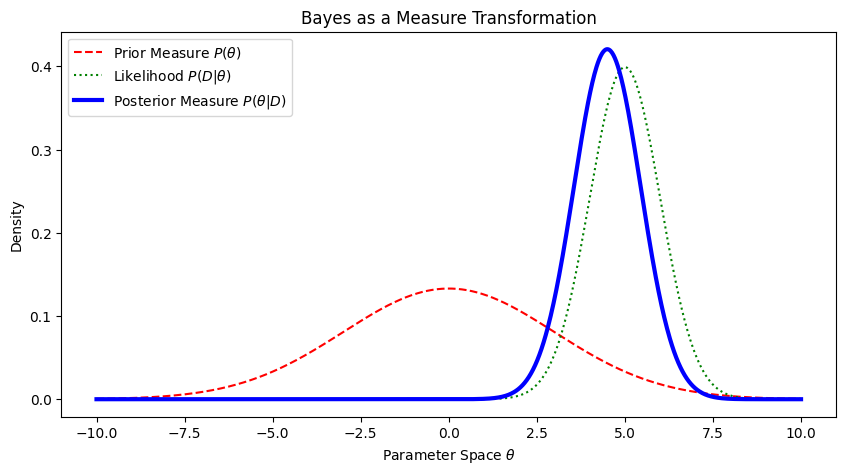

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Define the Prior Measure (Broad/Uncertain)
theta = np.linspace(-10, 10, 1000)
prior = norm.pdf(theta, loc=0, scale=3)

# 2. Define the Likelihood (Data suggests theta is near 5)
# Let's say we observed a data point x=5 with some noise
likelihood = norm.pdf(theta, loc=5, scale=1)

# 3. Compute Posterior (Element-wise product + Normalization)
unnormalized_posterior = likelihood * prior
posterior = unnormalized_posterior / np.trapezoid(unnormalized_posterior, theta)

plt.figure(figsize=(10, 5))
plt.plot(theta, prior, 'r--', label='Prior Measure $P(\\theta)$')
plt.plot(theta, likelihood, 'g:', label='Likelihood $P(D|\\theta)$')
plt.plot(theta, posterior, 'b-', lw=3, label='Posterior Measure $P(\\theta|D)$')

plt.title("Bayes as a Measure Transformation")
plt.xlabel("Parameter Space $\\theta$")
plt.ylabel("Density")
plt.legend()
plt.show()

# 4. The Conditional Expectation

## 4.1 Definition of the Conditional Expectation $(\mathbb{E}(X|Y))$



Let $(\Omega, \mathfrak{A}, P)$ be a probability space.

* Let $X: \Omega \to \mathbb{R}$ be a random variable that is integrable ($X \in L^1$).
* Let $Y: \Omega \to \mathbb{R}$ be another random variable.
* Let $\sigma(Y)$ be the **sub-$\sigma$-algebra** generated by $Y$. This represents "the information contained in $Y$."

---

**The Existence: Conditional Expectation**

The conditional expectation of $X$ given $Y$, denoted $\mathbb E[X|Y]$ (or more formally $\mathbb E[X|\sigma(Y)]$), is defined as the unique (almost surely) random variable $Z$ that satisfies two conditions:

1. **Measurability:** $Z$ is measurable with respect to $\sigma(Y)$.
*(Translation: $Z$ must be a function of $Y$. We can write $Z = g(Y)$.)*
2. **The Integral Property (Partial Averaging):** For every set $G \in \sigma(Y)$:

$$\int_G Z \, dP = \int_G X \, dP$$



*(Translation: On any set of outcomes that $Y$ can distinguish, the "average" of our estimate $Z$ must match the "average" of the actual $X$.)*

The existence and uniqueness of $Z$ are guaranteed by the **Radon-Nikodym Theorem**.



## 4.2 The Conditional Density ($f_{X\mid Y}$)

### 4.2.1 The Joint Probability ($P(X\in B\mid Y\in A)$)

Let
$$
Z_B\triangleq \mathbb E[\mathbb 1_{\{X\in B\}}\mid Y]\triangleq P(X\in B\mid Y).
$$

Since the event

$$
Y^{-1}(A)
$$

belongs to $\sigma(Y)$, the defining property of conditional expectation gives

$$
\int_{Y^{-1}(A)} Z_B\,dP=\int_{Y^{-1}(A)} \mathbb 1_{\{X\in B\}}\,dP.
$$

Substituting $P(X\in B\mid Y)$ for $Z_B$,

$$
\int_{Y^{-1}(A)} P(X\in B\mid Y)\,dP=\int_{Y^{-1}(A)} \mathbb 1_{\{X\in B\}}\,dP.
$$

Now note that

$$
\mathbb 1_{\{Y\in A\}}\mathbb 1_{\{X\in B\}}=\mathbb 1_{\{X\in B,\;Y\in A\}},
$$

so

$$
\int_{Y^{-1}(A)} \mathbb 1_{{X\in B}}\,dP
=\int_{\Omega} \mathbb 1_{\{X\in B\}}\mathbb 1_{\{Y\in A\}}\,dP=P(X\in B,\;Y\in A).
$$

Therefore

$$
P(X\in B,\;Y\in A)=\int_{Y^{-1}(A)} P(X\in B\mid Y)\,dP.
$$

---

$Z_B$ is measurable with respect to $\sigma(Y)$.
Hence from the Doob-Dynkin Lemma $Z_B$ must be a function of $Y$. We can write $Z_B = h_B(Y)$ and then the above expression can be written as:

$$
P(X\in B,\;Y\in A)=\int_{Y^{-1}(A)} h_B(Y)\,dP.
$$

Now applying the pushforward rule:
$$
\int_{Y^{-1}(A)} h_B(Y)\,dP=\int_A h_B(y)\,dP_Y(y),
$$

we have

$$
P(X\in B,\;Y\in A)=\int_A P(X\in B\mid Y=y)\,dP_Y(y).
$$

If $Y$ has density $f_Y$, so that

$$
dP_Y(y)=f_Y(y)\,dy,
$$

then this becomes

$$
P(X\in B,\;Y\in A)=\int_A P(X\in B\mid Y=y)\,f_Y(y)\,dy.
$$


A concise interpretation is:

> The joint probability $P(X\in B,\;Y\in A)$ is obtained by averaging the conditional probability $P(X\in B\mid Y=y)$ over all values $y\in A$, weighted by the distribution of $Y$.


Denote by $f_{X,Y}(x,y)$ the density of the joint distribution of $(X,Y)$ then
$$
P(X\in B,\;Y\in A)=\iint_{A\times B} f_{X,Y}(x,)\,dx\,\,dy.
$$



### 4.2.2 The Conditional Random Variable ($X \mid Y=y$)

The conditional measure $P_{X \mid Y=y}$ defined by
$$P_{X \mid Y=y}(B)\triangleq P(X \in B \mid Y=y).$$
If this measure is absolutely continuous with respect to the Lebesgue measure, then there exists a density $f_{X|Y}(x \mid y)$ such that:
$$
P(X \in B \mid Y=y)=P_{X \mid Y=y}(B)
=\int_B dP_{X \mid Y=y}= \int_B f_{X|Y}(x \mid y) \, dx.
$$
Specifically, if this measure is absolutely continuous with respect to the Lebesgue measure, the density $f_{X|Y}(x \mid y)$ is the Radon-Nikodym derivative of $P_{X \mid Y=y}$ with respect to the Lebesgue measure:
$$f_{X|Y}(x \mid y) = \frac{dP_{X \mid Y=y}}{dx}(x).$$

We define
$$X \mid Y=y$$
to be the unique random variable whose law is the conditional probability measure $P_{X \mid Y=y}$. Uniqueness follows from the uniqueness of the Radon-Nikodym derivative.

The expectation of this random variable is defined by

$$
\mathbb{E}(X\mid Y=y)\triangleq\int_{\mathscr{X}}x\,dP_{X \mid Y=y}(x)=\int_{\mathscr{X}}xf_{X|Y}(x \mid y)\,dx
$$

**Note that we have used parenthesis to distinguish from the conditional random varable $\mathbb{E}[X\mid Y]=g(Y)$. In this context $\mathbb{E}[X\mid Y=y]=g(y)$ and hence **.



### 4.2.3 The Product Rule of the Conditional Density

Substituting the above into the integral $
P(X\in B,\;Y\in A)=\int_A P(X\in B\mid Y=y)\,f_Y(y)\,dy
$ we have:
$$P(X \in B, Y \in A)
= \int_A \int_B f_{X|Y}(x \mid y) \, f_Y(y)\,dx \, dy.
$$

Since $P(X \in B, Y \in A) = \iint_{A \times B} f_{X,Y}(x,y) \, dx \, dy$ where $f_{X,Y}(x,y)$ is the joint probability density,
we obtain the product rule

$$
f_{X,Y}(x,y)=f_{X|Y}(x\mid y)f_Y(y)
$$
for almost every $(x,y)$.
The equality holds for the joint density $f_{X,Y}$ by the uniqueness of the Radon-Nikodym derivative.


---

**Discrete Product Rule**

The relationship $f_{X,Y}(x,y) = f_{X|Y}(x|y)f_Y(y)$ represents the "Product Rule" of probability, which in the discrete case is expressed as
$$p_{X,Y}(x,y) = p_{X|Y}(x|y)p_Y(y).$$ Rigorously, this formula is the realization of the measure-theoretic definition: $P(X \in B | Y) = \mathbb E[\mathbb{1}_B(X) | Y]$. In this context, $p_Y(y)$ is the marginal probability (the "weight" of a specific outcome of $Y$), and $p_{X|Y}(x|y)$ is the conditional probability (the "rescaled slice" of the joint distribution where $Y$ is fixed). By multiplying the localized probability of $X$ within a specific group by the total probability of that group occurring, we recover the joint probability of both events happening simultaneously.


### 4.2.4 The Disintegration Theorem

For any $A\in \mathscr{Y}$ the **Disintegration Theorem** states:

$$
\int_{Y^{-1}(A)} X \, dP = \int_A \left( \int_{\mathscr{X}} x \, dP_{X \mid Y=y}(x) \right) dP_Y(y)=\int_A \mathbb{E}(X\mid Y=y)\, dP_Y(y).
$$
Here **$\mathbb{E}(X \mid Y=y)$ is the expectation of the random variable $X\mid Y=y$ with respect to the conditional measure $P_{X \mid Y=y}$**.


The formal proof of this theorem is beyond the scope of this course. Intuitively, what it says is that the global average of a random variable $X$ over a specific region of the sample space can be calculated by "slicing" the sample space into fibers where $Y$ is fixed at a constant value $y$.

Within each fiber, we calculate the local average of $X$—this is the inner integral, which yields the conditional expectation $\mathbb{E}(X \mid Y=y)$. The theorem then tells us that the total average over the region $Y \in A$ is simply the weighted sum (or integral) of these local averages, where the weights are determined by the probability distribution of $Y$ itself.

In short, it justifies the "divide and conquer" strategy for computing expectations: you can break any complex distribution into a family of simpler conditional distributions, compute the averages locally, and then re-aggregate them to recover the global expectation.

**Note that $\mathbb{E}(X \mid Y=y)$ is the expectation of the random variable $(X\mid Y=y)$ with respect to the conditional measure $P_{X \mid Y=y}$. In contrast $\mathbb{E}[X \mid Y=y]=g(y)$ is the value of the conditional expectation random variable $\mathbb{E}[X|Y]$ evaluated at $Y=y$. However we will show below that the both values are the same and hence $\mathbb{E}(X \mid Y=y)=\mathbb{E}[X \mid Y=y]$.**

### 4.2.5 Expectation of $(X\mid Y=y)$ is the Same as the Conditional Expectation Evaluated at $Y=y$

We apply the definition of conditional expectation for a general random variable $X$ and using the Doob-Dynkin lemma we have for any $A\in \mathscr{Y}$:

$$
\int_{Y^{-1}(A)} X \, dP =
\int_{Y^{-1}(A)} \mathbb E[X \mid Y] \, dP =\int_A \mathbb E[X \mid Y=y] \, dP_Y(y).
$$

Note that in the previous section we have shown that the Disintegration Theorem gives
$$
\int_{Y^{-1}(A)} X \, dP = \int_A \left( \int_{\mathscr{X}} x \, dP_{X \mid Y=y}(x) \right) dP_Y(y)=\int_A \mathbb{E}(X\mid Y=y)\, dP_Y(y),
$$
where $\mathbb{E}(X\mid Y=y)$ was the expectation of the random variable $X\mid Y=y$ with respect to the conditional measure $P_{X \mid Y=y}$.

Thus we see that
$$\mathbb{E}[X\mid Y=y]=\mathbb{E}(X\mid Y=y)= \int_{-\infty}^{\infty} x \, dP_{X \mid Y=y}(x).
$$
The first term, $\mathbb{E}[X|Y=y]$, represents the evaluation of the $\sigma(Y)$-measurable random variable, while the second, $\mathbb{E}(X|Y=y)$, represents the integral against the conditional measure. The Disintegration Theorem proves these two objects are, in fact, the same $P_Y$-almost everywhere.


Given the assumption that the measure $P_{X \mid Y=y}$ is absolutely continuous with respect to the Lebesgue measure, we have the expression:

$$
\mathbb E[X \mid Y=y] = \int_{-\infty}^{\infty} x \, f_{X|Y}(x \mid y) \, dx
$$

Defining $g(y) \triangleq \mathbb E[X \mid Y=y]$, we arrive at:

$$
g(y) = \int_{-\infty}^{\infty} x \, f_{X|Y}(x \mid y) \, dx.
$$


---

**Summary: The Relationship Between $\mathbb E[X\mid Y]$ and $f_{X\mid Y}$**

> The conditional expectation $\mathbb E[X\mid Y]$ is the $\sigma(Y)$-measurable random variable:
$$\mathbb E[X\mid Y]=g(Y).$$ It'sevaluation at the random value $Y=y$ is given by the expression
> $$g(y)=\mathbb E[X\mid Y=y]=\int_{\mathscr{X}} x\,f_{X\mid Y}(x\mid y)\,dx.$$



## 4.4 The "Slice" Visual



Think of the joint distribution $f_{X,Y}$ as a 3D mountain range.

1. **Fixing $Y=y$** is like taking a vertical "chainsaw cut" through that mountain at a specific $y$-coordinate.
2. The resulting **silhouette** of the cut is the conditional distribution.
3. However, the area under that silhouette isn't 1 yet. We must **rescale** it (divide by the marginal $f_Y(y)$) to make it a valid probability distribution.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

# 1. Setup Joint Distribution (X and Y are correlated)
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]] # High correlation
joint_dist = multivariate_normal(mean, cov)

# 2. Define the Slice (Conditioning on Y = 1.5)
y_condition = 1.5

# Calculate Conditional Parameters for the Gaussian
# mu_x|y = mu_x + rho * (sigma_x / sigma_y) * (y - mu_y)
mu_cond = 0 + 0.8 * (1/1) * (y_condition - 0)
var_cond = (1 - 0.8**2) * 1
x_range = np.linspace(-3, 3, 500)
conditional_pdf = norm.pdf(x_range, mu_cond, np.sqrt(var_cond))

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Joint Distribution Contour
x_grid, y_grid = np.mgrid[-3:3:.01, -3:3:.01]
pos = np.dstack((x_grid, y_grid))
ax1.contourf(x_grid, y_grid, joint_dist.pdf(pos), cmap='Blues')
ax1.axhline(y_condition, color='red', linestyle='--', lw=2, label=f'Slice at Y={y_condition}')

ax1.set_title("Joint Distribution $P(X, Y)$")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend(loc='upper left')

# Subplot 2: The Conditional Distribution (The "Slice" result)
ax2.plot(x_range, conditional_pdf, color='darkblue', lw=3, label=f'$P(X | Y={y_condition})$')
ax2.fill_between(x_range, conditional_pdf, color='blue', alpha=0.2)
ax2.axvline(mu_cond, color='red', linestyle=':', label='Conditional Mean')

ax2.set_title(f"Conditional Distribution $P(X | Y={y_condition})$")
ax2.set_xlabel("X")
ax2.set_ylabel("Density")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What this visualization reveals**

1. **Coordinate Transformation:** On the left, we are in the $\mathbb{R}^2$ plane. On the right, we have collapsed the $Y$ dimension.
2. **Mean Shift:** Notice that because $X$ and $Y$ are positively correlated, conditioning on a high $Y$ value ($1.5$) shifted the center of the $X$ distribution to the right (to $1.2$).
3. **Uncertainty Reduction:** The width of the blue curve on the right is narrower than the total spread of $X$ on the left. This is because knowing $Y$ has reduced our uncertainty about $X$.

**Would you like me to show the math for how the Variance shrinks when we condition? (This is the foundation of how "Observation" reduces "Uncertainty" in engineering).**

### 4.1.2 Two Coin Toss Example

Let’s take a two-coin toss where **$X$** is the result of the first toss and **$Y$** is the total number of "Heads" across both tosses ($H=1, T=0$).

In this scenario, the joint probability **$p_{X,Y}(x,y)$** is the probability that the first coin is $x$ **and** the total count is $y$. To find the conditional probability **$p_{X|Y}(x|y)$**, we "slice" the joint table at a specific value of $y$ and divide by the marginal probability $p_Y(y)$. For instance, if we observe that there is exactly **one head total ($Y=1$)**, our "strategy" $P(X \in B | Y)$ updates: since the total could have come from $(H,T)$ or $(T,H)$, the probability that the first coin was a Head ($X=1$) becomes $0.5$. This perfectly demonstrates the product rule: the joint probability of the first coin being Heads while the total is one ($0.25$) is equal to the conditional probability ($0.5$) multiplied by the marginal probability of getting one head total ($0.5$).

| Outcome $(\omega)$ | $X$ (1st Coin) | $Y$ (Total Heads) | $P(\omega)$ |
| --- | --- | --- | --- |
| **(H, H)** | 1 | 2 | 0.25 |
| **(H, T)** | 1 | 1 | 0.25 |
| **(T, H)** | 0 | 1 | 0.25 |
| **(T, T)** | 0 | 0 | 0.25 |

---

**Verification of the Product Rule for $X=1, Y=1$:**

* **Marginal $p_Y(1)$**: $P(Y=1) = 0.25 + 0.25 = 0.5$ (The "weight" of the group).
* **Conditional $p_{X|Y}(1|1)$**: $0.25 / 0.5 = 0.5$ (The "rescaled slice").
* **Product**: $0.5 \times 0.5 = 0.25$, which is exactly the joint probability $p_{X,Y}(1,1)$.

## 4.5 Important Results

### 4.5.1 Law of Total Expectation

This is arguably one of the most elegant result in probability theory.

If you know the expected value of $X$ for every possible "slice" of $Y$, then the overall average of $X$ is simply the weighted average of those slices.

---

**The Measure-Theoretic Statement**

The law states:


$$\mathbb E[X] = \mathbb E[\mathbb E[X | \sigma(Y)]]$$

**The Intuition:**

* The inner expectation, $\mathbb E[X | \sigma(Y)]$, is your **Strategy** (the "Best Guess" function).
* The outer expectation, $\mathbb E[\cdot]$, averages that strategy over all possible realizations of $Y$.

---

**The Analytical Derivation (Using Densities)**

To see why this works in the lab, let's write it out using the "slice and divide" logic we derived:

1. **Start with the Conditional Mean for a point $y$:**

$$\mathbb E[X | Y=y] = \int_{\mathscr{X}} x \cdot f_{X|Y}(x|y) \, dx$$


2. **Take the expectation of that function over all $y$:**

$$\mathbb E[\mathbb E[X|Y]] = \int_{\mathscr{Y}} \left( \int_{\mathscr{X}} x \cdot f_{X|Y}(x|y) \, dx \right) f_Y(y) \, dy$$


3. **Use the Product Rule ($f_{X|Y} \cdot f_Y = f_{X,Y}$):**

$$\mathbb E[\mathbb E[X|Y]] = \int_{\mathscr{Y}} \int_{\mathscr{X}} x \cdot f_{X,Y}(x,y) \, dx \, dy$$


4. **Change the Order of Integration (Fubini's Theorem):**

$$\mathbb E[\mathbb E[X|Y]] = \int_{\mathscr{X}} x \left( \int_{\mathscr{Y}} f_{X,Y}(x,y) \, dy \right) dx$$


5. **Recognize the Marginal ($ \int f_{X,Y} dy = f_X(x)$):**

$$\mathbb E[\mathbb E[X|Y]] = \int_{\mathscr{X}} x \cdot f_X(x) \, dx = \mathbb E[X]$$



---

**The "Tower Property" Analogy**

Think of this as a **Tower**:

* **Ground Floor:** $\mathbb E[X]$. The raw average of the whole population.
* **First Floor:** $\mathbb E[X|Y]$. You’ve broken the population into groups (by $Y$). Each group has its own average.
* **The Result:** If you take the average of all the group averages (weighted by group size), you land back on the Ground Floor.

---





**Why this is Important:**

It allows us to solve complex problems by **Conditioning**. If you don't know how to calculate $\mathbb E[X]$ directly, you can:

1. Pick a variable $Y$ that "explains" $X$ well.
2. Calculate the mean of $X$ for each "slice" of $Y$ (usually easier).
3. Average those results.

#### Python Verification: "The Path of Means"

This code proves that the average of our "Red Regression Line" (from earlier) is exactly the global mean of $X$.

In [ ]:
import numpy as np

# Parameters
rho = 0.8
n_samples = 1_000_000

# 1. Generate Joint Data
y_samples = np.random.normal(5, 2, n_samples) # Mean 5, Std 2
x_samples = 0.8 * (y_samples - 5) + np.random.normal(10, 1, n_samples) # Mean 10

# 2. Calculate the Global Mean (Ground Floor)
global_mean_x = np.mean(x_samples)

# 3. Calculate Conditional Means (First Floor)
# For each y, our "Best Guess" strategy is h(y)
def h(y):
    # \mathbb E[X|Y=y] = mu_x + rho * (sigma_x/sigma_y) * (y - mu_y)
    # In this specific simulated case, the logic is:
    return 10 + 0.8 * (y - 5)

conditional_means = h(y_samples)

# 4. Law of Iterated Expectations: \mathbb E[h(Y)] should equal \mathbb E[X]
average_of_averages = np.mean(conditional_means)

print(f"Global Mean \mathbb E[X]:              {global_mean_x:.4f}")
print(f"Average of Conditional Means:  {average_of_averages:.4f}")
print(f"Difference:                    {abs(global_mean_x - average_of_averages):.6f}")

### 4.5.2 Conditional Variance ($\mathrm{Var}(X|Y)$)

In probability and statistical learning, we often seek to quantify how much of the uncertainty in a random variable $X$ can be explained by another variable $Y$.  

The Conditional Variance: $\mathrm{Var}(X|Y)$
The conditional variance is the variance of $X$ given a specific outcome of $Y$. Formally, it is a $\sigma(Y)$-measurable random variable defined as:
$$\mathrm{Var}(X|Y) = \mathbb E[X^2 | Y] - (\mathbb E[X|Y])^2$$
It measures the **residual uncertainty** of $X$ that remains after $Y$ is known. If you were to observe $Y=y$, the conditional variance tells you the spread of the remaining probability distribution of $X$.



### 4.5.3 Law of Total Variance

For any two random variables $X$ and $Y$ with finite variance, the total variance of $X$ can be split into two distinct parts:

$$\mathrm{Var}(X) = \mathbb E[\mathrm{Var}(X|Y)] + \mathrm{Var}(\mathbb E[X|Y])$$

* **$\mathrm{Var}(X)$**: Total Uncertainty (The "Total Spread").
* **$\mathbb E[\mathrm{Var}(X|Y)]$**: Unexplained Variance (The "Average Spread of the Slices").
* **$\mathrm{Var}(\mathbb E[X|Y])$**: Explained Variance (The "Spread of the Means").

---

**The Analytical Derivation**

We use the definition of variance $\mathrm{Var}(Z) = \mathbb E[Z^2] - (\mathbb E[Z])^2$ and the **Law of Iterated Expectations** to prove this.

**Step 1: Expand the Right Hand Side.**
Recall $\mathrm{Var}(X|Y) = \mathbb E[X^2|Y] - (\mathbb E[X|Y])^2$.
Taking the expectation of this "Slice Variance":


$$\mathbb E[\mathrm{Var}(X|Y)] = \mathbb E[\mathbb E[X^2|Y]] - \mathbb E[(\mathbb E[X|Y])^2]$$

By the Law of Iterated Expectations, $\mathbb E[\mathbb E[X^2|Y]] = \mathbb E[X^2]$. So:


$$\mathbb E[\mathrm{Var}(X|Y)] = \mathbb E[X^2] - \mathbb E[(\mathbb E[X|Y])^2] \quad \text{--- (Equation A)}$$

**Step 2: Expand the Variance of the Mean.**


$$\mathrm{Var}(\mathbb E[X|Y]) = \mathbb E[(\mathbb E[X|Y])^2] - (\mathbb E[\mathbb E[X|Y]])^2$$

Again, by Iterated Expectations, $\mathbb E[\mathbb E[X|Y]] = \mathbb E[X]$. So:


$$\mathrm{Var}(\mathbb E[X|Y]) = \mathbb E[(\mathbb E[X|Y])^2] - (\mathbb E[X])^2 \quad \text{--- (Equation B)}$$

**Step 3: Add (A) and (B).**
Notice that the $\mathbb E[(\mathbb E[X|Y])^2]$ terms cancel out:


$$\mathbb E[\mathrm{Var}(X|Y)] + \mathrm{Var}(\mathbb E[X|Y]) = \mathbb E[X^2] - (\mathbb E[X])^2$$

This is exactly the definition of **$\mathrm{Var}(X)$**.

---

**The Physical Intuition**

Imagine you are measuring the height ($X$) of students across different ages ($Y$).

* **$\mathrm{Var}(X)$**: The total variation in height if you ignore age.
* **$\mathbb E[\mathrm{Var}(X|Y)]$**: The variation in height *within* each age group (e.g., the spread of 10-year-olds). This is what your model **cannot** explain.
* **$\mathrm{Var}(\mathbb E[X|Y])$**: How much the *average* height changes as you move from age 5 to age 20. This is the information that Age ($Y$) **successfully explains**.

---

> **The Shrinkage Principle:** Since $\mathrm{Var}(\mathbb E[X|Y]) \geq 0$, it is mathematically guaranteed that $\mathbb E[\mathrm{Var}(X|Y)] \leq \mathrm{Var}(X)$. Observing $Y$ can never make you *more* confused on average; it either helps or stays the same.



In [ ]:
import numpy as np

# Generate correlated data
n = 10**6
y = np.random.normal(0, 10, n)
# X is dependent on Y + some noise
x = 0.5 * y + np.random.normal(0, 5, n)

# 1. Total Variance
total_var = np.var(x)

# 2. Explained Variance (Variance of the "Prediction" \mathbb E[X|Y])
# For this linear case, \mathbb E[X|Y] is simply 0.5 * Y
prediction = 0.5 * y
explained_var = np.var(prediction)

# 3. Unexplained Variance (Average variance of the slices/residuals)
residuals = x - prediction
unexplained_var = np.mean(residuals**2) # Since mean of residuals is 0

print(f"Total Variance:      {total_var:.4f}")
print(f"Explained + Unexpl.: {explained_var + unexplained_var:.4f}")
print(f"R-squared (Explained/Total): {explained_var/total_var:.4f}")

#### 4.5.3.1 The Two Coin Toss Example

**Global Variance $\mathrm{Var}(X)$**

First, we look at $X$ alone. Since $X$ is a Bernoulli trial (fair coin), its mean is $\mathbb E[X] = 0.5$.


$$\mathrm{Var}(X) = \mathbb E[X^2] - (\mathbb E[X])^2 = (1^2 \cdot 0.5 + 0^2 \cdot 0.5) - (0.5)^2 = 0.5 - 0.25 = \mathbf{0.25}$$


This represents our **Total Uncertainty** about the first coin before we know anything about the total count.

---

**The Partition (Law of Total Variance)**

Now we apply: $\mathrm{Var}(X) = \mathbb E[\mathrm{Var}(X|Y)] + \mathrm{Var}(\mathbb E[X|Y])$.

**Part A: The "Strategy" $\mathbb E[X|Y]$ (Explained Variance)**

We calculate the "Best Guess" of $X$ for every possible value of $Y$:

* If $Y=0$, then $X$ must be $0$. So $\mathbb E[X|Y=0] = \mathbf{0}$.
* If $Y=1$, then $X$ could be $0$ or $1$ (equally likely). So $\mathbb E[X|Y=1] = \mathbf{0.5}$.
* If $Y=2$, then $X$ must be $1$. So $\mathbb E[X|Y=2] = \mathbf{1}$.

Now, we find the variance of these guesses (weighted by $p_Y$):


$$Var(\mathbb E[X|Y]) = \underbrace{(0^2 \cdot 0.25 + 0.5^2 \cdot 0.5 + 1^2 \cdot 0.25)}_{\mathbb E[(\mathbb E[X|Y])^2]} - \underbrace{(0.5)^2}_{(\mathbb E[X])^2}$$

$$\mathrm{Var}(\mathbb E[X|Y]) = (0 + 0.125 + 0.25) - 0.25 = \mathbf{0.125}$$


**This is the "Explained Variance":** Knowing $Y$ explains $50\%$ of the uncertainty in $X$.

**Part B: The "Residuals" $\mathbb E[Var(X|Y)]$ (Unexplained Variance)**

We calculate the "Spread" of $X$ within each slice of $Y$:

* Slice $Y=0$: $X$ is always $0 \implies Var(X|Y=0) = \mathbf{0}$.
* Slice $Y=1$: $X$ is a fair coin $\implies Var(X|Y=1) = \mathbf{0.25}$.
* Slice $Y=2$: $X$ is always $1 \implies Var(X|Y=2) = \mathbf{0}$.

Now, average these slices:


$$\mathbb E[Var(X|Y)] = (0 \cdot 0.25) + (0.25 \cdot 0.5) + (0 \cdot 0.25) = \mathbf{0.125}$$


**This is the "Unexplained Variance":** The uncertainty left over when the total heads is 1.

---

**Summary of the Results**

| Component | Value | Interpretation |
| --- | --- | --- |
| **$Var(X)$** | **0.25** | Total uncertainty (Raw data). |
| **$Var(\mathbb E[X | Y])$** | **0.125** |
| **$\mathbb E[Var(X | Y)]$** | **0.125** |

**Check:** $0.125 (\text{Explained}) + 0.125 (\text{Unexplained}) = 0.25 (\text{Total})$.

---

**Conclusion:**

By observing $Y$, we have cut our uncertainty about $X$ exactly in half. In "Information Theory" terms, we would say $Y$ provides information about $X$. If $Y$ and $X$ were independent, the explained variance would be $0$, and we would be just as confused as when we started.

#5. Entropy

In the most rigorous sense—the one that bridges Information Theory and Measure Theory—**Entropy is a property of the probability measure.**

However, in practice, we usually describe it as a property of the **distribution** (the Law) of a random variable. To be precise: the random variable $X$ is simply the "delivery vehicle" for the measure.

## 5.1 The Measure-Theoretic View (Relative Entropy)

**Relative entropy** (also called **Kullback-Leibler divergence**) is a measure of how one probability measure differs from another.

If $P$ and $Q$ are two probability measures on the same measurable space $(\Omega,\mathfrak F)$, and $P$ is absolutely continuous with respect to $Q$ ($P \ll Q$), then the relative entropy of $P$ with respect to $Q$ is defined by

$$
D_{KL}(P\|Q)=\int_{\Omega}\ln\left(\frac{dP}{dQ}\right)\,dP
$$

equivalently,

$$
D_{KL}(P\|Q)=\int_{\Omega}\frac{dP}{dQ}\ln\left(\frac{dP}{dQ}\right)\,dQ.
$$

Here $\frac{dP}{dQ}$ is the **Radon-Nikodym derivative** of $P$ with respect to $Q$.

So relative entropy is fundamentally a comparison between two probability measures. It does not require introducing a random variable explicitly; it only requires that the two measures are defined on the same measurable space.

---

For two discrete probability distributions $P$ and $Q$ on the same countable alphabet $\mathfrak X$, the relative entropy is

$$
D_{KL}(P\|Q)=\sum_{x\in\mathfrak X} P(x)\ln\left(\frac{P(x)}{Q(x)}\right).
$$

In the discrete case, the Radon-Nikodym derivative reduces to the ratio

$$
\frac{dP}{dQ}(x)=\frac{P(x)}{Q(x)}
\quad\text{whenever } Q(x)>0.
$$

**Condition for finiteness:**

For $D_{KL}(P\|Q)$ to be well defined as an extended value, it is enough to require $P \ll Q$. Under this condition, the KL divergence may still be finite or $+\infty$.

For the discrete case, absolute continuity means:

> whenever $Q(x)=0$, we must also have $P(x)=0$.

If there exists some $x$ such that $P(x)>0$ but $Q(x)=0$, then

$$
D_{KL}(P\|Q)=+\infty.
$$



## 5.2 The Distribution View (Differential Entropy)

If $X$ has a distribution on $\mathbb R^n$ that is absolutely continuous with respect to some probability measure $\mu$ (on $\mathbb R^n$ one may take the Lebesgue measure $\mu=\lambda^n$), then there exists a density $f$ such that

$$
dP_X(x)=f(x)\,d\mu(x).
$$

The **differential entropy** of $X$ is then defined by

$$
h_{\mu}(X) = -\int_{\mathbb R^n} f(x)\ln f(x)\,d\mu(x),
$$

provided the integral is well defined.

Equivalently, since $f=\frac{dP_X}{d\mu}$, we may write

$$
h_{\mu}(X) = -\int_{\mathbb R^n} \ln\left(\frac{dP_X}{d\mu}\right)\,dP_X=-\mathbb{E}\left(\ln(f(X))\right).
$$

Thus, in the continuous setting, differential entropy is a property of the distribution $P_X$ through its density relative to the measure $\mu$.


> Here $\mu$ is a reference measure on the **target space** where $X$ takes values, not the underlying probability measure on $(\Omega,\mathfrak A)$; thus differential entropy is defined from the law $P_X$ relative to a chosen measure on the state space.

## 5.4 Entropy of a Discrete Random Variable (Shannon Entropy)

Certainly. Here is the analogous version for a **discrete random variable**.

If $X$ is a discrete random variable taking values in a countable set $S$, then its law $P_X$ is absolutely continuous with respect to the **counting measure** $\mu$ on $S$. In this case, the density of $P_X$ with respect to $\mu$ is just the probability mass function

$$
p(x)=P_X({x}), \qquad x\in S.
$$

Thus we may write

$$
dP_X(x)=p(x)\,d\mu(x),
$$

where $\mu$ is counting measure on $S$.

The **entropy** of $X$ is then defined by

$$
H(X)=-\sum_{x\in S} p(x)\ln p(x),
$$

provided the sum is well defined.

Equivalently, since

$$
p=\frac{dP_X}{d\mu},
$$

we may write

$$
H(X)=-\sum_{x\in S}\ln\left(\frac{dP_X}{d\mu}(x)\right)\,P_X({x})
=
-\int_S \ln\left(\frac{dP_X}{d\mu}\right)\,dP_X.
$$

That is,

$$
H(X)=-\mathbb E[\ln p(X)].
$$

Thus, in the discrete setting, entropy is a property of the distribution $P_X$ through its density relative to counting measure on the state space.

> Here $\mu$ is the counting measure on the **target space** where $X$ takes values, not the underlying probability measure on $(\Omega,\mathfrak A)$; thus entropy is defined from the law $P_X$ relative to a chosen reference measure on the state space.

A concise parallel with the continuous case is:

* **Discrete case:** reference measure = counting measure
* **Continuous case:** reference measure = Lebesgue measure

So in both cases, entropy has the common form

$$
-\int \ln\left(\frac{dP_X}{d\mu}\right)\,dP_X.
$$

The only difference is the choice of reference measure $\mu$.


## 5.4 Visualizing Entropy as "Spread" of Measure

The higher the entropy, the more "spread out" the probability measure is. A "spike" (Delta measure) has zero entropy (perfect certainty).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Define two probability measures (distributions)
# P1: Concentrated (Low Entropy)
# P2: Spread out (High Entropy)
x = np.linspace(0, 10, 100)
p1 = np.exp(-(x-5)**2 / (2 * 0.5**2))
p1 /= p1.sum()

p2 = np.exp(-(x-5)**2 / (2 * 2.0**2))
p2 /= p2.sum()

plt.figure(figsize=(10, 4))
plt.fill_between(x, p1, alpha=0.5, label=f'Low Entropy: {entropy(p1):.2f}')
plt.fill_between(x, p2, alpha=0.5, label=f'High Entropy: {entropy(p2):.2f}')
plt.title("Entropy as a Property of the Measure's Concentration")
plt.legend()
plt.show()

## 5.4 Mutual Information

Mutual Information measures how far the joint distribution $P_{X,Y}$ is from the case where $X$ and $Y$ are independent ($P_X \otimes P_Y$).

$$I(X;Y) \triangleq D_{KL}(P_{X,Y} \, \| \, P_X P_Y)$$

Using the Radon-Nikodym derivative (the ratio of densities), this is defined as:


$$I(X;Y) = \int_{\mathfrak{X} \times \mathfrak{Y}} f_{X,Y}(x,y) \ln \left( \frac{f_{X,Y}(x,y)}{f_X(x) f_Y(y)} \right) dx \, dy$$

---

The **Conditional Differential Entropy** of $X$ given $Y$ is defined by

$$
h(X|Y)
=-\mathbb E\left[\ln f_{X|Y}(X|Y)\right].
$$
It measures the average uncertainty remaining in $X$ after $Y$ is observed. **Note that this is completely different from $h(\mathbb{E}(X|Y))$**.

Equivalently, if $(X,Y)$ has joint density $f_{X,Y}(x,y)$ and $Y$ has marginal density $f_Y(y)$, then

$$
h(X|Y)=
-\int\int f_{X,Y}(x,y)\ln f_{X|Y}(x|y),dx,dy.
$$

Since

$$
f_{X|Y}(x|y)=\frac{f_{X,Y}(x,y)}{f_Y(y)},
$$

one also gets

$$
h(X|Y)=h(X,Y)-h(Y).
$$

---

**Relationship Between Mutual Information and Conditional Entropy**

Starting from mutual information,

$$
I(X;Y)=\iint f_{X,Y}(x,y)\ln\frac{f_{X,Y}(x,y)}{f_X(x)f_Y(y)}\,dx\,dy,
$$

use

$$
f_{X,Y}(x,y)=f_{X|Y}(x|y)f_Y(y)
$$

to get

$$
I(X;Y)=\iint f_{X,Y}(x,y)\ln\frac{f_{X|Y}(x|y)}{f_X(x)}\,dx\,dy.
$$

Then

$$
I(X;Y)
=\iint f_{X,Y}(x,y)\ln f_{X|Y}(x|y)\,dx\,dy
=\iint f_{X,Y}(x,y)\ln f_X(x)\,dx\,dy
-h(X|Y)+h(X).
$$

Hence

$$
h(X|Y)=h(X)-I(X;Y).
$$

**Summary**

> Mutual Information is the **"Universal Information Gain."** It is the reduction in the entropy of $X$ achieved by observing $Y$. In other words it measures the percentage of **total uncertainty** (entropy) removed.


---

**Application to the Two-Coin Example**

Recall our discrete table. We can calculate the Mutual Information in **bits** (use $\log$ instead of $\ln$):

1. **$H(X)$**: A fair coin has $1$ bit of entropy.
2. **$H(X|Y)$**:
* If $Y=0$ or $Y=2$, entropy is $0$ (we know $X$ perfectly).
* If $Y=1$, entropy is $1$ bit ($X$ is still a fair coin).
* Average: $\mathbb E[H(X|Y)] = (0.25 \cdot 0) + (0.5 \cdot 1) + (0.25 \cdot 0) = \mathbf{0.5 \text{ bits}}$.


3. **$I(X;Y)$**: $1 \text{ bit} - 0.5 \text{ bits} = \mathbf{0.5 \text{ bits}}$.

**Physical Interpretation:** Knowing the total number of heads ($Y$) provides exactly **half a bit** of information about the first coin ($X$).

---



**Effect of Measurement Noise**


**Example.** Let $X$ be the true value of a physical quantity and let $Y=X+N$ be a noisy sensor reading, where $X\sim N(0,\sigma_X^2)$ and $N\sim N(0,\sigma_N^2)$ are independent. Then
$$
h(X)=\frac{1}{2}\ln(2\pi e\,\sigma_X^2),
$$
$$
I(X;Y)=\frac{1}{2}\ln\left(1+\frac{\sigma_X^2}{\sigma_N^2}\right),
$$
and
$$
h(X|Y)=\frac{1}{2}\ln\left(2\pi e\,\frac{\sigma_X^2\sigma_N^2}{\sigma_X^2+\sigma_N^2}\right).
$$
Hence
$$
h(X|Y)=h(X)-I(X;Y).
$$
This means that the uncertainty remaining in the true signal after observing the noisy measurement equals the original uncertainty minus the information gained from the measurement.


If the sensor is very noisy, then $\sigma_N^2$ is large:

* $I(X;Y)$ is small,
* so $h(X|Y)$ remains close to $h(X)$.

That means the measurement does not reduce uncertainty very much.

If the sensor is very accurate, then $\sigma_N^2$ is small:

* $I(X;Y)$ is large,
* so $h(X|Y)$ becomes much smaller than $h(X)$.

That means the measurement provides a lot of information about the true temperature.

# 6. The Bridge to Statistical Learning: LLN and CLT

This section serves as the "Grand Finale," connecting your abstract definitions of probability spaces and random variables to the practical realities of data science and statistical learning.



In the previous sections, we treated probability measures and random variables as abstract mathematical objects. However, in **Statistical Learning**, we never observe the "true" probability measure $\mu$; we only observe finite samples. The **Law of Large Numbers (LLN)** and the **Central Limit Theorem (CLT)** provide the mathematical guarantees that allow us to reconstruct the "truth" from these samples.

## 6.1 The Law of Large Numbers (LLN)

The LLN is the formal justification for using the **Empirical Distribution** proesented above as a proxy for the population. It states that as our sample size $n$ grows, the sample average converges to the theoretical expectation (the Lebesgue integral) defined in Section 2.2.1.

Let $(\Omega, \mathfrak{F}, P)$ be a probability space and let $X_1, X_2, \dots, X_n$ be a sequence of i.i.d. random variables. Assume the expectation exists such that $\mathbb{E}[|X|] < \infty$, where the expectation is defined as the Lebesgue integral:


$$\mathbb{E}[X] = \int_{\Omega} X(\omega) \, dP(\omega)$$

Let $\mathbb{E}[X_i] = \mu$ and $\mathrm{Var}(X_i) = \sigma^2 < \infty$.


The **sample average** (or empirical mean) is defined as:


$$\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$$






### 6.1.1 Weak Law of Large Numbers

The Weak Law of Large Numbers states that the sample average converges **in probability** to the theoretical mean:


$$\bar{X}_n \xrightarrow{P} \mu.$$

#### Proof

Using the linearity of the Lebesgue integral (from your Section 2.2.1):


$$\mathbb{E}[\bar{X}_n] = \frac{1}{n} \sum_{i=1}^n \mathbb{E}[X_i] = \frac{n\mu}{n} = \mu$$


Because the variables are independent, the variances add:


$$\mathrm{Var}(\bar{X}_n) = \mathrm{Var}\left(\frac{1}{n} \sum X_i\right) = \frac{1}{n^2} \sum Var(X_i) = \frac{n\sigma^2}{n^2} = \frac{\sigma^2}{n}$$

Applying Chebyshev's Inequality we have that for any $\epsilon > 0$, the probability that the sample mean deviates from the true mean is bounded by:


$$P(|\bar{X}_n - \mu| \geq \epsilon) \leq \frac{\mathrm{Var}(\bar{X}_n)}{\epsilon^2} = \frac{\sigma^2}{n\epsilon^2}$$
As $n \to \infty$, the right-hand side goes to zero. Thus, $\bar{X}_n \xrightarrow{P} \mu$.

### 6.1.2 Strong Law of Large Numbers

The Strong Law of Large Numbers states that the sample average converges to the theoretical mean **almost surely** ($P$-a.s.):


$$P\left( \lim_{n \to \infty} \bar{X}_n = \mathbb{E}[X] \right) = 1$$

This is more rigorous because it says the limit holds for nearly every individual outcome $\omega$ in your sample space $\Omega$.

#### Sketch of Proof

**The Logic (Borel-Cantelli approach):**
To prove that $\bar{X}_n \to \mu$ almost surely, we need to show that the probability of the "tail" events (where the error stays large) is zero.

1. **Fourth Moment Bound:** If we assume $\mathbb{E}[X^4] < \infty$, we can show that $P(|\bar{X}_n - \mu| \geq \epsilon) \leq \frac{C}{n^2}$ for some constant $C$.
2. **Summability:** Unlike the $1/n$ in the Weak Law, the sequence $1/n^2$ is **summable** ($\sum_{n=1}^\infty \frac{1}{n^2} < \infty$).
3. **Borel-Cantelli Lemma:** Since the sum of the probabilities of these "bad" events is finite, the lemma states that these events occur only **finitely many times** for almost every $\omega$.
4. **Conclusion:** Therefore, after some finite $n$, the sample mean stays within $\epsilon$ of $\mu$ forever.

## 6.2 The Central Limit Theorem (CLT)

While the LLN tells us *where* the sample mean is going, the CLT tells us the **shape of the uncertainty** along the way.

That is as $n \to \infty$, the standardized sample mean converges in distribution to the standard Normal distribution $\mathfrak{N}(0,1)$.

**Central Limit Theorme**

Let $\{X_1, X_2, \dots, X_n\}$ be a sequence of **i.i.d.** random variables defined on a probability space $(\Omega, \mathfrak{F}, P)$. Assume they have a finite mean $\mathbb{E}[X_i] = \mu$ and a finite variance $Var(X_i) = \sigma^2 > 0$.

The standardized sample mean $Z_n$ is defined as:


$$Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} = \frac{\sum_{i=1}^n (X_i - \mu)}{\sigma\sqrt{n}}$$


As $n \to \infty$, $Z_n$ converges in distribution to the standard Normal distribution:


$$Z_n \xrightarrow{d} \mathfrak{N}(0, 1)$$

#### Proof

**Step 1: Simplify the Variables**
Let $Y_i = \frac{X_i - \mu}{\sigma}$. By the linearity of expectation and properties of variance:

* $\mathbb{E}[Y_i] = 0$
* $Var(Y_i) = 1$
We can now rewrite $Z_n$ as: $Z_n = \frac{1}{\sqrt{n}} \sum_{i=1}^n Y_i$.

**Step 2: Use the Characteristic Function**
The characteristic function of a random variable $Y$ is defined as $\varphi_Y(t) = \mathbb{E}[e^{itY}]$.
Since $Z_n$ is a sum of independent variables, its characteristic function factorizes:


$$\varphi_{Z_n}(t) = \mathbb{E}\left[e^{it \frac{1}{\sqrt{n}} \sum Y_i}\right] = \mathbb{E}\left[\prod_{i=1}^n e^{it \frac{Y_i}{\sqrt{n}}}\right] = \left[ \varphi_Y\left(\frac{t}{\sqrt{n}}\right) \right]^n$$

**Step 3: Taylor Expansion of $\varphi_Y$**
Since $\mathbb{E}[Y] = 0$ and $\mathbb{E}[Y^2] = 1$, we expand $\varphi_Y$ around zero using a Taylor series:


$$\varphi_Y(u) = \mathbb{E}[e^{iuY}] = \mathbb{E}\left[ 1 + iuY + \frac{(iuY)^2}{2!} + o(u^2) \right]$$

$$\varphi_Y(u) = 1 + i(0) - \frac{u^2}{2}(1) + o(u^2) = 1 - \frac{u^2}{2} + o(u^2)$$


Substituting $u = \frac{t}{\sqrt{n}}$:


$$\varphi_Y\left(\frac{t}{\sqrt{n}}\right) = 1 - \frac{t^2}{2n} + o\left(\frac{t^2}{n}\right)$$

**Step 4: Take the Limit as $n \to \infty$**
Now we substitute this back into the expression for $\varphi_{Z_n}(t)$:


$$\varphi_{Z_n}(t) = \left[ 1 - \frac{t^2}{2n} + o\left(\frac{t^2}{n}\right) \right]^n$$


Using the fundamental limit identity $\lim_{n \to \infty} (1 + \frac{x}{n})^n = e^x$, we get:


$$\lim_{n \to \infty} \varphi_{Z_n}(t) = e^{-t^2/2}$$

**Step 5: Lévy’s Continuity Theorem**
The function $e^{-t^2/2}$ is the characteristic function of the **Standard Normal Distribution** $\mathfrak{N}(0, 1)$. According to Lévy’s Continuity Theorem, if a sequence of characteristic functions converges to the characteristic function of a distribution, the random variables converge in distribution.

**Conclusion:**


$$Z_n \xrightarrow{d} \mathfrak{N}(0, 1)$$

This confirms that the "spiky" empirical averages eventually form the smooth Gaussian bell curve as the "resolution" of our information increases.

## 6.3 Strong Law for Empirical Frequencies

For a set of $n$ independent and identically distributed (i.i.d.) samples $X_1, X_2, \dots, X_n$ from a probability space $(\Omega, \mathfrak{F}, P)$, the empirical measure is defined for any measurable event $A \in \mathfrak{F}$ as:

$$P_n(A) = \frac{1}{n} \sum_{i=1}^n \delta_{X_i}(A) = \frac{1}{n} \sum_{i=1}^n \mathbb{1}_A(X_i)$$

Where:

* $\delta_{X_i}(A)$ is the **Dirac measure** (the "spike"), which is $1$ if $X_i \in A$ and $0$ otherwise.


* $\mathbb{1}_A(X_i)$ is the **Indicator Function**, which treats the occurrence of the event as a Bernoulli trial.



The Glivenko-Cantelli Theorem gives that

**Theorem:** Let $X_1, X_2, \dots$ be i.i.d. random variables. For any fixed measurable set $A$, the empirical measure $P_n(A)$ converges to the true measure $P(A)$ **almost surely** ($P$-a.s.):


$$P\left( \lim_{n \to \infty} P_n(A) = P(A) \right) = 1$$

### The Sketch of the Proof

The proof relies on treating the indicator functions as a new sequence of random variables.

**Step 1: Transformation to Bernoulli Variables**
Define a new sequence of random variables $Y_i = \mathbb{1}_A(X_i)$.

* Because the $X_i$ are i.i.d., the $Y_i$ are also i.i.d..


* $Y_i$ follows a Bernoulli distribution where "success" is the event $X_i \in A$.



**Step 2: Expectation of the Indicator**
Using the definition of expectation as a **Lebesgue integral** from your Section 2.2.1:


$$\mathbb{E}[Y_i] = \mathbb{E}[\mathbb{1}_A(X_i)] = \int_{\Omega} \mathbb{1}_A(\omega) \, dP(\omega) = P(A)$$

This shows that the "theoretical mean" of our indicator variables is exactly the probability of the event $A$.

**Step 3: Application of the Strong Law of Large Numbers**
The Empirical Measure $P_n(A)$ is simply the **sample average** of these $Y_i$ variables:


$$P_n(A) = \frac{1}{n} \sum_{i=1}^n Y_i$$

According to the **Strong Law of Large Numbers**, the sample average of i.i.d. variables with finite expectation converges almost surely to that expectation:


$$\frac{1}{n} \sum_{i=1}^n Y_i \xrightarrow{a.s.} \mathbb{E}[Y_1]$$


Substituting our values:


$$P_n(A) \xrightarrow{a.s.} P(A)$$